Arjun Joshi. Brainstation Capstone <br>
December, 2024<br>
Diploma Program: Data Science

<html>
<style>
sup {
    vertical-align: super;
    font-size: smaller;
}
</style>
<p>
<sub><h3><center>Capstone. Case Study: Application of Anthropogenic WSM </center></h3></sub>
<sup></sup><h1> <center>DATA CLEANING, EDA & PRE-PROCESSING</sup>
<sup><h3> .ANTHROPOGENIC PRESSURES. </h3></sup><center></center></h1>
</html>


##### Run intro scripts

In [6]:
import os 

In [7]:

# Set working directory to notebook dir

os.chdir('J:/Brainstation/BS Git/Tampa_Apollo_AnthropogenicIndex/notebooks')

In [10]:
#Load libraries
%run scripts/imports
%run scripts/DataDictionary.py
%run scripts/stored_functions.py
pd.set_option('display.max_columns', None) #make cell output scrollable to examine features in dfs with many features

## Introduction

### Context

As stated in the ReadMe, 3 supplementary notebooks cover cleaning, EDA, requisite baseline modelling for each individual environment/ecosystem/overarching framework - which are ultimately used to measure the performance of the Anthropogenic Pressure Index (API)

Figure 1 below shows the geography, scale and basic information about the Tampa Region. The marked area in white in the top left image shows the town where the marine construction in this case study has been proposed.

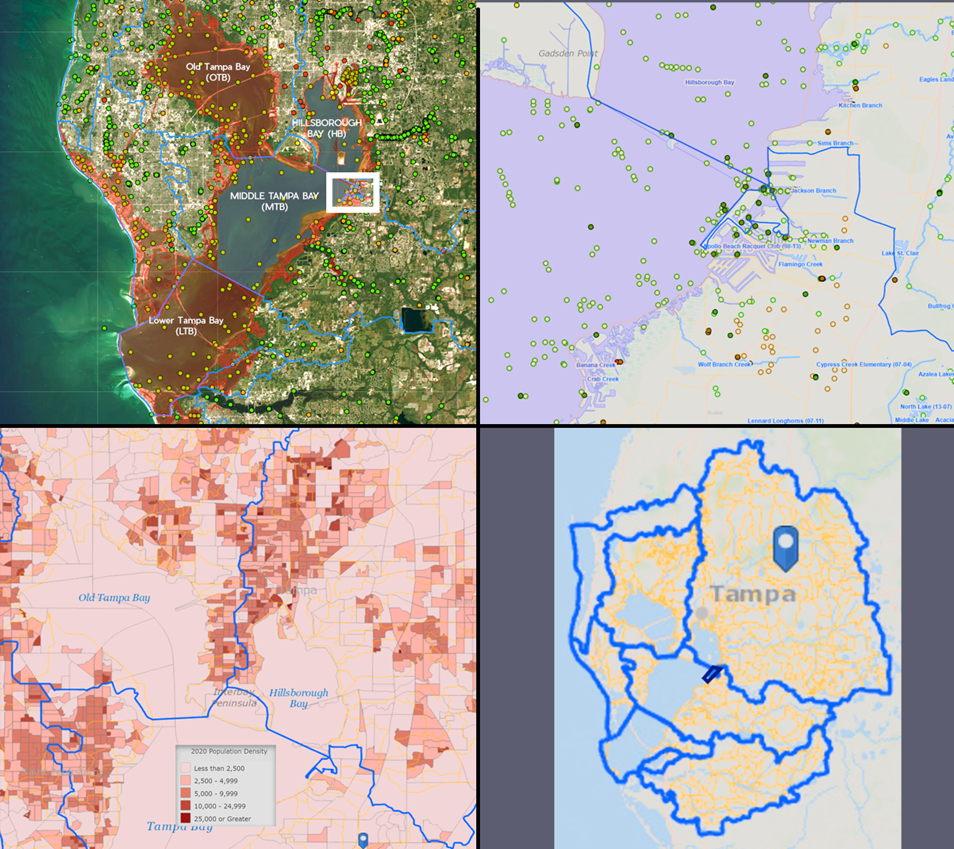

<sup>Figure1.<br>
> (A) Top L. marked sections of Tampa Bay <br>
> (B) Top R. Sampling Sites Near Proposed Construction site. prominent filled circles are active, all others are not inactive <br>
> (C) Bottom L. 2020 Population Density of Tampa Bay Region <br>
> (D) Bottom R. The massive scale of the watershed, the marked area is the HB watershed and the one directly underneath is MTB. <br>Marking in the >     center of the the image is the proposed study site </sup>


>>> Regional Watershed Area Descriptions.<br>
>>> **HB Watershed**: Area (Sq Miles) : 1,281.83 <br>
>>> **MTB watershed**: Area (Sq Miles) : 410.31 <br>

When considering the nutrient loading, nitrogen in particular, it's important to understand the scale of the watershed - all of which flows into the bay. The H.C. is massive, covering nearly 1300 sq miles. That area includes large amounts of agricultral land, new residential and commercial construction.

Notebook Context: This notebook processes what is considered to be data describing Anthropogenic Pressures on the coastal ecosystem.
Notebook Purpose: Clean, Pre-process Anth.Gen. data, including EDA and baseline modelling, in order to establish crucial relationships between features.<br> This notebook requires an understanding of Nitrogen compounds in the ecosystem, if they're organic or not and their patterns over time. Unlike the biology specific data, Anth. Gen. data obtained has a sampling structure and consistency to attempt a Time-Series Analysis.
<br>
<br>
*I encourage anyone reviewing the code to utilize the Table of Contents for easy navigation.*<br>
Each subcategory has it's own section for cleaning, EDA, processing and baselines modelling (if applicable)
There are 3 major areas of focus covered, the notebook is also organized accordingly:<BR>
1. Section: Nitrate Concentrations, Water Quality (ADF, TSA)
2. Section: Property Development Metrics
3. Section: Population Growth Metrics (Linear Regression)


##### Post-Intro Note : 2 Features Omitted

*Two additional possible sources of anth. pressures were in the original design of the study: marine recreational traffic and geospatial analysis. These were omitted because it was not feasible to get records of marine traffic without paying a respectable amount for GIS-hosted GPS data for vessels. Data obtained did not include GPS during a trip, only start, end and if any stops were made or ports called upon. Geospatial data had to be omitted due to loss of data due to hardware issues. This will be pursued in subsequent expansion on this study.*

*Please refer to the ReadMe for a more detailed look into the complexities and impacts of Anth. Gen. on coastal marine ecosystems.*

### Definitions, Read Data

#### Definitions

#### Read CSV into Pandas DF

##### Nutrient Loading Data

In [25]:
os.chdir('J:\\Brainstation\\BS Git\\data\\human Imact\\MarineTraffic')

In [15]:
# There are 4 sections of Tampa Bay.
# This study covers 2 but can expanded to all. Refer to map in introduction section

# Import Middle Tampa Bay (MTB) Water Quality (WQ) data. 1990-2024
mtbwq=pd.read_csv('MTB_WQ.csv',low_memory=False)

# Import Hillsborough Bay (HB) W.Q. data. 1990-2024
hbwq=pd.read_csv('HB_WTQ.csv',low_memory=False)

FileNotFoundError: [Errno 2] No such file or directory: 'MTB_WQ.csv'

##### Property Development

In [16]:

os.chdir('J:/Brainstation/BS Git/Property Records')

In [9]:
proprx=pd.read_csv('PRIMARY_PROPRX.csv',low_memory='False')

C:\Users\Ajax\AppData\Local\Temp\ipykernel_61040\3142466767.py:1: DtypeWarning: Columns (1,4,38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  proprx=pd.read_csv('PRIMARY_PROPRX.csv',low_memory='False')


In [10]:
# Old Table read-ins from design phase using subset data
# Subset dfs
# Original Sectioned Property Records
AB_1=pd.read_csv('AB_1.csv')
AB_2=pd.read_csv('AB_BLVD_SPIT_1.csv')
AB_3=pd.read_csv('AB_Central_1.csv')
AB_4=pd.read_csv('AB_INTSXN_1.csv')
AB_5=pd.read_csv('AB_SOUTH_1.csv')
AB_6=pd.read_csv('AB_SOUTH_2.csv')
AB_7=pd.read_csv('AB_SPIT_1.csv')
GIB_8=pd.read_csv('GIB_MAIN_1.csv')
RIV_1=pd.read_csv('RIV_W_1.csv')

##### Population Growth

In [11]:
os.chdir('J:\\Brainstation\\BS Git\\data\\human Imact\\MarineTraffic')

In [12]:
#WHO population figures
dfpop_staged=pd.read_csv('StagedPopulations.csv')

In [13]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\human Imact\\Population Data')

In [14]:
#Hillsborough county sourced data, metro area (subset)
pop_metro=pd.read_csv('tampa_metro_population.csv',header=0)

## Feature Space 1: Nitrate Loading; Water Quality Index

Tables loaded in at start of notebook.<br>Tables:<BR>
> _(hbwq)_   Hillsborough Bay (HB)<br>
> _(mtbwq)_ Middle Tampa Bay (MTB)<br>
These 2 data sets are closest in proximmity to the study site, the focus of the study. <br>
This dataset can always be expanded at a later date.

Objective: <BR>Establish clear pattern between 3 forms of Nitrogen compounds in the bay:<br>
Nitrates and Nitrates (NO3,NO2-).   Ammonia/Ammonium (NH3).       Organic Nitrogen.

Key Info:<BR>
Nitrates/Nitrites (NO3, No2-), and ammonia(NH3/NH4+) are inorganic forms of nitrogen and either represent the slow breakdown of organic material or input from external sources. Part 1 must demonstrate that NH3 and N03 compound(s) vary, with significance, from behaviors and patterns observed in Organic Nitrogen.
mtbwq.head(5)

In [165]:
# Df read-in check
hbwq.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude_DD,Longitude_DD,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fluorides,1.00,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fecal Coliform,10.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved Solids,27200.00,mg/l,NaN,NaN,20005,Hillsborough Bay
3,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen saturation,80.80,percent (%),NaN,NaN,20005,Hillsborough Bay
4,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen (DO),4.68,mg/l,NaN,NaN,20005,Hillsborough Bay


In [166]:
# Df read-in check
mtbwq.head(5)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Actual_Latitude,Actual_Longitude,DEP_WBID,SampleDate,...,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l
3,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,NO3_ugl,"Nitrogen, Nitrate (NO3) as N",NaN,10.0,NaN,NaN,NaN,0.01,mg/l
4,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,pH,pH,NaN,8.3,NaN,NaN,NaN,8.3,NaN


In [167]:
#null check
print(mtbwq.isna().sum())
hbwq.isna().sum()

WBodyID                       0
WaterBodyName                 0
DataSource                    0
StationID                     0
StationName                   0
Actual_StationID              0
Actual_Latitude               0
Actual_Longitude              0
DEP_WBID                      0
SampleDate                    0
ActivityDepth             47806
DepthUnits                    0
Parameter                     0
Characteristic             5507
Sample_Fraction          505439
Result_Value                  0
Result_Unit              102440
QACode                   449145
Result_Comment           501969
Original_Result_Value    153389
Original_Result_Unit     167747
dtype: int64


DataSourceName             0
DataSourceCode             0
StationID                  0
ActualStationID      1048575
Latitude_DD                0
Longitude_DD               0
SampleDate                 0
SampleTime                 0
ActivityDepth         766156
ActivityDepthUnit     758436
Characteristic        748461
ResultValue              985
ResultUnit            786325
ValueQualifier       1005190
ResultComment        1035222
WaterbodyID                0
WaterbodyName              0
dtype: int64

In [168]:
# Checking column names
mtbwq.Actual_Latitude
mtbwq.columns[[6,7]]

Index(['Actual_Latitude', 'Actual_Longitude'], dtype='object')

In [169]:
# Standardizing some columns between these 2 datasets

In [170]:
hbwq.rename(columns={'Latitude_DD':'Latitude','Longitude_DD':'Longitude'},inplace=True)
hbwq.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fluorides,1.00,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Fecal Coliform,10.00,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved Solids,27200.00,mg/l,NaN,NaN,20005,Hillsborough Bay
3,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen saturation,80.80,percent (%),NaN,NaN,20005,Hillsborough Bay
4,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,4/25/2006,0:00:00,0.2,m,Dissolved oxygen (DO),4.68,mg/l,NaN,NaN,20005,Hillsborough Bay


In [171]:
# Standardizing some columns between these 2 datasets

In [172]:
mtbwq.rename(columns={'Actual_Latitude':'Latitude','Actual_Longitude':'Longitude'},inplace=True)
mtbwq.head(5)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,...,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l
3,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,NO3_ugl,"Nitrogen, Nitrate (NO3) as N",NaN,10.0,NaN,NaN,NaN,0.01,mg/l
4,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,7/10/1972 0:00,...,m,pH,pH,NaN,8.3,NaN,NaN,NaN,8.3,NaN


In [173]:
hbwq.Characteristic.value_counts()

Characteristic
Temperature, water                               45421
Salinity                                         33622
Specific conductance                             31115
Dissolved oxygen (DO)                            30145
pH                                               29934
                                                 ...  
Manganese                                            2
Nickel                                               2
Zinc                                                 2
Nitrogen, Nitrite (NO2) as N                         2
Anatoxin (toxin produced by blue green algae)        1
Name: count, Length: 61, dtype: int64

** This study uses Organic and Inorganic forms of nitrogen and phosphorous as a proxy for anthropogenic introduction of harmful chemicals into the bay. This study examines these 2 features in 2 main ways:<br>
- As an aggregate statistic that describes the functioning of the bay at large
- The  ratio of organic to inorganic  compounds that describe that extent of anthropogenic and ultimately harmful versions of these compounds introduced.

In [174]:
# looking specifically for the forms of Nitrogen.
# Nitrogen comes in Nitrogen Organic, Nitrogen, Nitrates, Nitrites, Ammonia, Ammonium

# HBWQ - Hillsborough Bay Water Quality
# MTBWQ - Middle Tampa Bay Water Quality

index_1=hbwq.Characteristic.str.contains('Nit,nit').index==True

In [175]:
len(index_1)

1048575

In [176]:
# Isolate Nit. in HB
Nit=hbwq.Characteristic.str.contains('Nitrogen')

In [177]:
Nit.head()

0    False
1    False
2    False
3    False
4    False
Name: Characteristic, dtype: object

In [178]:
# Phosphate isolation. Omitted.
# Remnant from initial EDA 
pho_hb=hbwq.Characteristic.str.contains('Phosph')

### Data Wrangling, EDA / Pre-Processing

#### WQI Sample Frequency, Consistency Check

In [179]:
# Begin EDA, aggregations for patterns
hbwq.SampleDate.str.slice(-4).value_counts().reset_index().sort_values(by='SampleDate')

,SampleDate,count
29,1990,5554
27,1991,6780
22,1992,10118
25,1993,7243
30,1994,5342
28,1995,5786
33,1996,4647
34,1997,4210
32,1998,4774
31,1999,5241


In [180]:
hbwq.SampleDate=pd.to_datetime(hbwq.SampleDate)

In [181]:
mtbwq.SampleDate=pd.to_datetime(mtbwq.SampleDate)

In [182]:
# Sanity Check
hbwq.head(3)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Fluorides,1.0,mg/l,NaN,NaN,20005,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Fecal Coliform,10.0,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-04-25,0:00:00,0.2,m,Dissolved Solids,27200.0,mg/l,NaN,NaN,20005,Hillsborough Bay


In [183]:
mtbwq.head(3)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,...,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,...,m,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l
1,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,...,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,550.0,NaN,NaN,NaN,0.55,mg/l
2,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,...,m,NH3_N_ugl,"Nitrogen, ammonia as N",NaN,580.0,NaN,NaN,NaN,0.58,mg/l


    SampleDate  count
10           1    419
9            2    439
6            3    462
11           4    346
0            5    530
7            6    455
8            7    450
2            8    499
1            9    500
5           10    481
3           11    491
4           12    482


array([[<Axes: title={'center': 'SampleDate'}>,
        <Axes: title={'center': 'count'}>]], dtype=object)

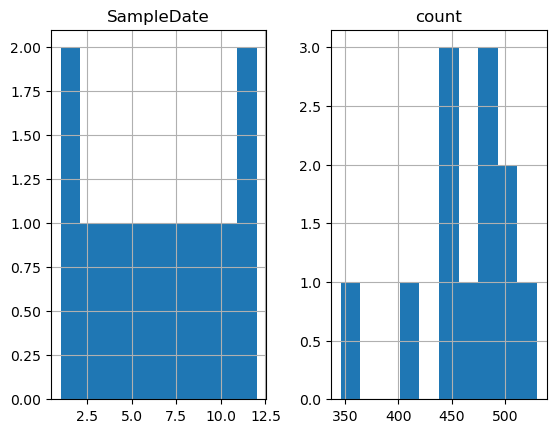

In [184]:
#Look at sample counts over time.
print(hbwq[hbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate'))
hbwq[hbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate').hist()

    SampleDate  count
6            1    795
7            2    791
9            3    766
10           4    718
2            5    827
4            6    805
8            7    786
1            8    886
3            9    809
0           10    981
11          11    658
5           12    803


array([[<Axes: title={'center': 'SampleDate'}>,
        <Axes: title={'center': 'count'}>]], dtype=object)

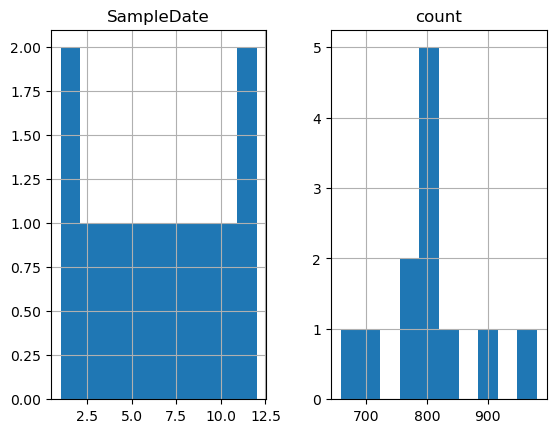

In [185]:
# Checking for distribution of sample counts by month
print(mtbwq[mtbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate'))
mtbwq[mtbwq.SampleDate.dt.year==1990].SampleDate.dt.month.value_counts().reset_index().sort_values(by='SampleDate').hist()

#### _Preliminary EDA and processing of subset, 1990, used in initial EDA and construction of baseline models. CODE OUTDATED_

In [186]:
# MTB. HB. Isolate for 1990
mtbwq1990=mtbwq[mtbwq.SampleDate.dt.year==1990]
hbwq1990=hbwq[hbwq.SampleDate.dt.year==1990]

In [187]:
# Exploring at data for 1 month
mtbwq1990[mtbwq1990.SampleDate.dt.month==1].sort_values(by='SampleDate')

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,...,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
510825,20007,Middle Tampa Bay,HCEPC_WQ,32,Tampa Bay Marker 5G,"=""32""",27.7931,-82.570600,1558C,1990-01-03 00:00:00,...,m,Cond_umhocm,Specific conductance,NaN,45300.00,umho,NaN,NaN,NaN,NaN
130386,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,...,m,Turb_ntu,Turbidity,NaN,3.00,NTU,NaN,NaN,NaN,NaN
130385,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,...,m,Tcoli_100ml,Total Coliform,NaN,4.00,cfu/100ml,NaN,NaN,NaN,NaN
130384,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,...,m,TKN_ugl,"Nitrogen, Kjeldahl",NaN,680.00,ug/l,NaN,NaN,NaN,NaN
130383,20007,Middle Tampa Bay,HCEPC_WQ,33,Lower Old Tampa Bay,"=""33""",27.8261,-82.567500,1558C,1990-01-03 00:00:00,...,m,Fcoli_100ml,Fecal Coliform,NaN,4.00,cfu/100ml,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82437,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,...,m,TP_mgl,Phosphorus as P,NaN,0.52,mg/l,NaN,NaN,0.52,mg/L
82438,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,...,m,TKN_mgl,"Nitrogen, Kjeldahl",NaN,1.31,mg/l,NaN,NaN,1.31,mg/L
82439,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,...,m,TN_mgl,Nitrogen,NaN,1.38,mg/l,C,NaN,1.38,mg/L
82427,20007,Middle Tampa Bay,EPC_ROUTINE_MONITORING,136,Cockroach Bay,"=""136""",27.6800,-82.499199,1778,1990-01-31 11:12:00,...,m,norg_ugl,"Nitrogen, organic",NaN,1270.00,ug/l,C,NaN,1.27,mg/L


In [188]:
# Format dt values
mtbwq.SampleDate=pd.to_datetime(mtbwq.SampleDate)
hbwq.SampleDate=pd.to_datetime(hbwq.SampleDate)

<Axes: >

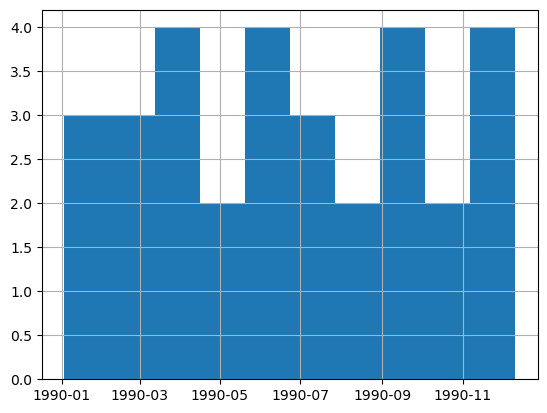

In [189]:
# Look at sampling
hbwq1990_samplefreq=hbwq1990.SampleDate.value_counts().reset_index().sort_values(by='SampleDate').reset_index(drop=True)
hbwq1990_samplefreq.SampleDate.hist()

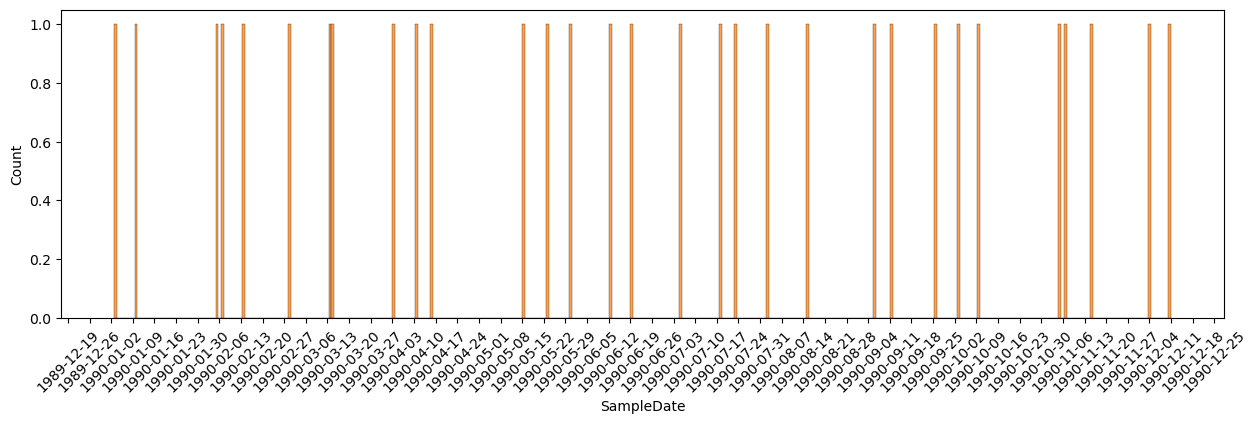

In [190]:
# Looking for missing weekly samples
import matplotlib.dates as mdates

plt.figure(figsize=(15,4))
sns.histplot()
ax = sns.histplot(x=hbwq1990_samplefreq.SampleDate,bins=365)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
#plt.xticks(range('1990-01-01','1990-12-31', 365))
plt.show()

In [191]:
#sanity
hbwq1990.head(2)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
22449,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-01-10,0:00:00,2.23,m,Fecal Coliform,4.0,cfu/100ml,NaN,NaN,20005,Hillsborough Bay
22450,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-02-14,0:00:00,2.44,m,Fecal Coliform,4.0,cfu/100ml,NaN,NaN,20005,Hillsborough Bay


In [192]:
# Isolate Nitrates, complete examination of subset of data
nitrogen_1990=hbwq1990[hbwq1990.Characteristic.str.contains('Nitr','nitr')==True]
nitrogen_1990.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
22768,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-01-10,0:00:00,2.23,m,Nitrogen,930.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22769,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-02-14,0:00:00,2.44,m,Nitrogen,1120.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22770,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-03-14,0:00:00,2.59,m,Nitrogen,720.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22771,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-04-11,0:00:00,2.59,m,Nitrogen,610.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22772,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-05-16,0:00:00,2.59,m,Nitrogen,940.0,ug/l,NaN,NaN,20005,Hillsborough Bay


##### EDA: Isolation of Nitrogen Compounds, 1990 subset

The dataset has multiple entries for each sample event. The same sample is analyzed and described in multiple ways. Consequently, data needs to be isolated to get a consistent single data set.

In [193]:
# Create Phosphate df
phosphate_hb=hbwq[hbwq.Characteristic.str.contains('Phos','phos')==True]
phosphate_hb.SampleDate=pd.to_datetime(phosphate_hb.SampleDate)
phosphate_hb.head(2)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\345737480.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phosphate_hb.SampleDate=pd.to_datetime(phosphate_hb.SampleDate)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
21,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-10-03,0:00:00,0.2,m,Phosphorus as P,280.0,ug/l,NaN,NaN,20005,Hillsborough Bay
22,FDEP Southwest Regional Operations Center,STORET_21FLTPA,2.74734E+14,NaN,27.792639,-82.413861,2006-10-03,0:00:00,0.2,m,"Phosphorus, phosphate (PO4) as P",0.2,mg/l,NaN,NaN,20005,Hillsborough Bay


In [194]:
#Isolate Phosphate
phosphate_1990=hbwq1990[hbwq1990.Characteristic.str.contains('Phos','phos')==True]
phosphate_1990.head(5)

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
23711,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-12-11,0:00:00,0.91,m,"Phosphorus, phosphate (PO4) as P",0.30,mg/l,NaN,NaN,20005,Hillsborough Bay
25728,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-06-13,0:00:00,1.07,m,Phosphorus as P,0.65,mg/l,NaN,NaN,20005,Hillsborough Bay
25729,EPC Water Quality Data,HCEPC_WQ,44,NaN,27.923609,-82.480832,1990-10-10,0:00:00,0.91,m,Phosphorus as P,0.42,mg/l,NaN,NaN,20005,Hillsborough Bay
25764,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-09-12,0:00:00,2.44,m,Phosphorus as P,0.63,mg/l,NaN,NaN,20005,Hillsborough Bay
25849,EPC Water Quality Data,HCEPC_WQ,6,NaN,27.889443,-82.477497,1990-02-14,0:00:00,1.52,m,Phosphorus as P,0.52,mg/l,NaN,NaN,20005,Hillsborough Bay


In [195]:
# Checking Units
pd.concat([nitrogen_1990.Characteristic.value_counts(),nitrogen_1990.ResultUnit.value_counts()],axis=1)

,count,count
"Nitrogen, Kjeldahl",362.0,NaN
Nitrogen,349.0,NaN
"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",338.0,NaN
"Nitrogen, ammonia as N",319.0,NaN
"Nitrogen, organic",311.0,NaN
"Nitrogen, Nitrate (NO3) as N",14.0,NaN
mg/l,NaN,831.0
ug/l,NaN,699.0


In [196]:
# Isolate Nit
nitrate1990=nitrogen_1990[nitrogen_1990.Characteristic.str.contains('Nitrogen, Nitrite')]
print(nitrate1990.shape)
nitrate1990.reset_index(drop=True,inplace=True)
nitrate1990.head(3)

(338, 17)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-01-10,0:00:00,1.68,m,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",10.0,ug/l,NaN,NaN,20005,Hillsborough Bay
1,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-02-14,0:00:00,1.68,m,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",20.0,ug/l,NaN,NaN,20005,Hillsborough Bay
2,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-03-14,0:00:00,1.83,m,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",10.0,ug/l,NaN,NaN,20005,Hillsborough Bay


In [197]:
# Test nitrate isolation
nitrate1990[nitrate1990.ResultUnit.isna()]
nitrate1990.ResultUnit.fillna('ug/l',inplace=True)
nitrate1990[nitrate1990.ResultUnit.isna()]

C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\2110313770.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nitrate1990.ResultUnit.fillna('ug/l',inplace=True)
C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\2110313770.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitrate1990.ResultUnit.fillna('ug/l',inplace=True)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName


In [198]:
# Standardize units
for i in nitrate1990.index:
    if nitrate1990.loc[i,'ResultUnit']=='ug/l':
        nitrate1990.loc[i,'ResultValue']=nitrate1990.loc[i,'ResultValue']/1000
        nitrate1990.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [199]:
# Create subset with features of interest
nitrate_subset=nitrate1990[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude']]

In [200]:
# date format
nitrate_subset['month']=nitrate_subset.SampleDate.dt.month
nitrate_subset

C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\958506387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitrate_subset['month']=nitrate_subset.SampleDate.dt.month


,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month
0,EPC Water Quality Data,7,1990-01-10,0:00:00,0.010,mg/l,27.858887,-82.468609,1
1,EPC Water Quality Data,7,1990-02-14,0:00:00,0.020,mg/l,27.858887,-82.468609,2
2,EPC Water Quality Data,7,1990-03-14,0:00:00,0.010,mg/l,27.858887,-82.468609,3
3,EPC Water Quality Data,7,1990-04-11,0:00:00,0.020,mg/l,27.858887,-82.468609,4
4,EPC Water Quality Data,7,1990-05-16,0:00:00,0.010,mg/l,27.858887,-82.468609,5
...,...,...,...,...,...,...,...,...,...
333,EPC Monthly Routine Water Monitoring,44,1990-07-18,9:50:00,0.003,mg/l,27.923700,-82.480698,7
334,EPC Monthly Routine Water Monitoring,2,1990-10-10,9:30:00,0.020,mg/l,27.940800,-82.457901,10
335,EPC Monthly Routine Water Monitoring,52,1990-11-07,14:51:00,0.020,mg/l,27.896999,-82.438202,11
336,USGS National Water Information System,2.75134E+14,1990-02-07,0:00:00,0.040,mg/l,27.859747,-82.451205,2


In [201]:
# look at nitrate patterns over 1 year period
nitrate_subset_plot=nitrate_subset.groupby('month').ResultValue.agg(['mean','std','min','max'])
nitrate_subset_plot.head(12)

,mean,std,min,max
month,,,,
1,0.022138,0.031466,0.003,0.15
2,0.020667,0.013374,0.010,0.08
3,0.011304,0.003444,0.010,0.02
4,0.013107,0.009171,0.003,0.03
5,0.007826,0.005140,0.003,0.02
6,0.009552,0.005779,0.003,0.02
7,0.009769,0.005969,0.003,0.02
8,0.009455,0.009145,0.003,0.05
9,0.009552,0.006905,0.003,0.03


In [202]:
# Isolate ammmonia
ammonia1990=nitrogen_1990[nitrogen_1990.Characteristic.str.contains('ammon')].sort_values(by='SampleDate').reset_index(drop=True)
print(ammonia1990.shape)
ammonia1990.head()

(319, 17)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
0,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,2,NaN,27.940800,-82.457901,1990-01-10,13:45:00,0.30,m,"Nitrogen, ammonia as N",0.02,mg/l,JI,NaN,20005,Hillsborough Bay
1,EPC Water Quality Data,HCEPC_WQ,6,NaN,27.889443,-82.477497,1990-01-10,0:00:00,1.52,m,"Nitrogen, ammonia as N",40.00,NaN,NaN,NaN,20005,Hillsborough Bay
2,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,44,NaN,27.923700,-82.480698,1990-01-10,10:45:00,0.70,m,"Nitrogen, ammonia as N",30.00,ug/l,JI,NaN,20005,Hillsborough Bay
3,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,58,NaN,27.939800,-82.419601,1990-01-10,9:47:00,1.50,m,"Nitrogen, ammonia as N",0.06,mg/l,JI,NaN,20005,Hillsborough Bay
4,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,71,NaN,27.876499,-82.413803,1990-01-10,14:27:00,1.10,m,"Nitrogen, ammonia as N",40.00,ug/l,JI,NaN,20005,Hillsborough Bay


In [203]:
# Check for units for standardization
ammonia1990.ResultUnit.value_counts()

ResultUnit
mg/l    168
ug/l    100
Name: count, dtype: int64

In [204]:
# Will need to standardize units
ammonia1990[ammonia1990.ResultUnit=='ug/l'].ResultValue

2       30.0
4       40.0
8       60.0
9       20.0
10     100.0
       ...  
306     20.0
313     50.0
314     40.0
315     20.0
316     90.0
Name: ResultValue, Length: 100, dtype: float64

In [205]:
# Std. ammonia units
for i in ammonia1990.index:
    if ammonia1990.loc[i,'ResultUnit']=='ug/l':
        ammonia1990.loc[i,'ResultValue']=ammonia1990.loc[i,'ResultValue']/1000
        ammonia1990.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [206]:
ammonia1990.ResultUnit.value_counts()

ResultUnit
mg/l    268
Name: count, dtype: int64

In [207]:
ammonia_subset=ammonia1990[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude']]

In [208]:
#Drop amm. dupes
print(ammonia_subset.duplicated().value_counts())
ammonia_subset=ammonia_subset.drop_duplicates()
print(ammonia_subset.duplicated().value_counts())
ammonia_subset.head(5)

False    254
True      65
Name: count, dtype: int64
False    254
Name: count, dtype: int64


,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude
0,EPC Monthly Routine Water Monitoring,2,1990-01-10,13:45:00,0.02,mg/l,27.940800,-82.457901
1,EPC Water Quality Data,6,1990-01-10,0:00:00,40.00,NaN,27.889443,-82.477497
2,EPC Monthly Routine Water Monitoring,44,1990-01-10,10:45:00,0.03,mg/l,27.923700,-82.480698
3,EPC Monthly Routine Water Monitoring,58,1990-01-10,9:47:00,0.06,mg/l,27.939800,-82.419601
4,EPC Monthly Routine Water Monitoring,71,1990-01-10,14:27:00,0.04,mg/l,27.876499,-82.413803


In [209]:
# any null values would be in ug/l format
ammonia_subset.ResultUnit.fillna('ug/l',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\3432828705.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ammonia_subset.ResultUnit.fillna('ug/l',inplace=True)


In [210]:
# Standardize 
for i in ammonia_subset.index:
    if ammonia_subset.loc[i,'ResultUnit']=='ug/l':
        ammonia_subset.loc[i,'ResultValue']=ammonia1990.loc[i,'ResultValue']/1000
        ammonia_subset.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [211]:
# date format
ammonia_subset['month']=ammonia_subset.SampleDate.dt.month

In [212]:
# aggregate amm. to monthly for 1 year, look at patterns
ammonia_subset_plot=ammonia_subset.groupby('month').ResultValue.agg(['mean','std','min','max'])
ammonia_subset_plot.head(12)

,mean,std,min,max
month,,,,
1,0.056111,0.024044,0.02,0.10
2,0.048571,0.029204,0.02,0.11
3,0.046842,0.013355,0.02,0.07
4,0.049545,0.032142,0.01,0.11
5,0.049200,0.023965,0.01,0.10
6,0.082105,0.066297,0.01,0.19
7,0.044783,0.042412,0.01,0.17
8,0.092917,0.053931,0.02,0.20
9,0.076522,0.069649,0.01,0.19


In [213]:
pwd

'J:\\Brainstation\\BS Git\\data\\human Imact\\MarineTraffic'

<Axes: xlabel='month', ylabel='mean'>

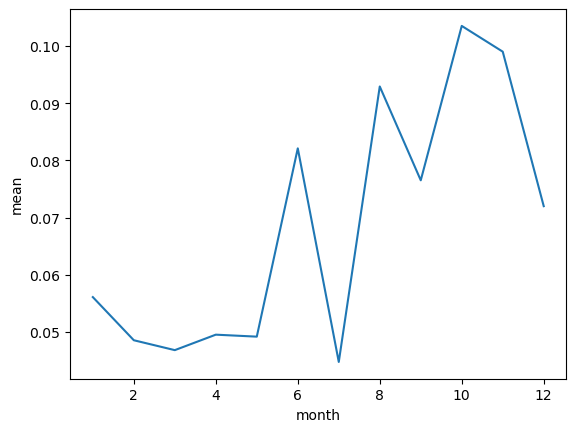

In [214]:
# look at monthly aggreate patterns for 1 year
sns.lineplot(x='month',y='mean',data=ammonia_subset_plot,errorbar=('ci',95))

Kjeldahl units are a measurement of nitrogen that typically represents concentrations of organic Nitrogen. It is an engineered measurement, where a water sample is treated with a catalytic agent to convert nitrogen into ammonia, similar to the decomposition process.

In [215]:
# Isolation kjedahl measurements
kjedahl=nitrogen_1990[nitrogen_1990.Characteristic.str.contains('Kjeld')]
print(kjedahl.shape)
kjedahl.head(5)

(362, 17)


,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
25672,EPC Water Quality Data,HCEPC_WQ,55,NaN,27.849166,-82.431385,1990-04-11,0:00:00,2.59,m,"Nitrogen, Kjeldahl",0.60,mg/l,NaN,NaN,20005,Hillsborough Bay
25735,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-02-14,0:00:00,1.68,m,"Nitrogen, Kjeldahl",1.13,mg/l,NaN,NaN,20005,Hillsborough Bay
25736,EPC Water Quality Data,HCEPC_WQ,7,NaN,27.858887,-82.468609,1990-08-15,0:00:00,2.13,m,"Nitrogen, Kjeldahl",0.76,mg/l,NaN,NaN,20005,Hillsborough Bay
25739,EPC Water Quality Data,HCEPC_WQ,70,NaN,27.908888,-82.463055,1990-07-18,0:00:00,1.52,m,"Nitrogen, Kjeldahl",0.38,mg/l,NaN,NaN,20005,Hillsborough Bay
25884,EPC Water Quality Data,HCEPC_WQ,6,NaN,27.889443,-82.477497,1990-07-18,0:00:00,1.98,m,"Nitrogen, Kjeldahl",0.61,mg/l,NaN,NaN,20005,Hillsborough Bay


In [216]:
print(kjedahl.ResultUnit.isna().value_counts())
kjedahl.ResultUnit.value_counts()

ResultUnit
False    340
True      22
Name: count, dtype: int64


ResultUnit
mg/l    170
ug/l    170
Name: count, dtype: int64

In [217]:
# Look at units
kjedahl[kjedahl.ResultUnit=='ug/l'].head()

,DataSourceName,DataSourceCode,StationID,ActualStationID,Latitude,Longitude,SampleDate,SampleTime,ActivityDepth,ActivityDepthUnit,Characteristic,ResultValue,ResultUnit,ValueQualifier,ResultComment,WaterbodyID,WaterbodyName
26914,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-12-11,10:00:00,1.6,m,"Nitrogen, Kjeldahl",460.00001,ug/l,NaN,NaN,20005,Hillsborough Bay
27002,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-10-10,10:30:00,1.7,m,"Nitrogen, Kjeldahl",479.99999,ug/l,NaN,NaN,20005,Hillsborough Bay
27034,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-09-12,10:33:00,1.8,m,"Nitrogen, Kjeldahl",649.99998,ug/l,NaN,NaN,20005,Hillsborough Bay
27062,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-08-15,10:29:00,2.0,m,"Nitrogen, Kjeldahl",810.00000,ug/l,NaN,NaN,20005,Hillsborough Bay
27093,EPC Monthly Routine Water Monitoring,EPC_ROUTINE_MONITORING,6,NaN,27.889299,-82.477402,1990-07-18,10:18:00,2.0,m,"Nitrogen, Kjeldahl",610.00001,ug/l,NaN,NaN,20005,Hillsborough Bay


In [218]:
# std. kjel units
for i in kjedahl.index:
    if kjedahl.loc[i,'ResultUnit']=='ug/l':
        kjedahl.loc[i,'ResultValue']=kjedahl.loc[i,'ResultValue']/1000
        kjedahl.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [219]:
kjedahl.reset_index(drop=True,inplace=True)
kjedahl.sort_values(by='SampleDate').reset_index(drop=True,inplace=True)

In [220]:
#date format
kjedahl['month']=kjedahl.SampleDate.dt.month

C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\1304643865.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kjedahl['month']=kjedahl.SampleDate.dt.month


In [221]:
# isolate kjel features of interest
kjedahl_subset=kjedahl[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude','month']]

In [222]:
# sanity check
kjedahl_subset.head(5)

,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month
0,EPC Water Quality Data,55,1990-04-11,0:00:00,0.60,mg/l,27.849166,-82.431385,4
1,EPC Water Quality Data,7,1990-02-14,0:00:00,1.13,mg/l,27.858887,-82.468609,2
2,EPC Water Quality Data,7,1990-08-15,0:00:00,0.76,mg/l,27.858887,-82.468609,8
3,EPC Water Quality Data,70,1990-07-18,0:00:00,0.38,mg/l,27.908888,-82.463055,7
4,EPC Water Quality Data,6,1990-07-18,0:00:00,0.61,mg/l,27.889443,-82.477497,7


In [223]:
# search for inconsistent values, outlier values
kjedahl_subset[kjedahl_subset.ResultValue>2]

,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month
235,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,520.0,NaN,27.859747,-82.451205,5
236,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,530.0,NaN,27.859747,-82.451205,5
237,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,560.0,NaN,27.859747,-82.451205,5
238,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,570.0,NaN,27.859747,-82.451205,5
239,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,580.0,NaN,27.859747,-82.451205,5
240,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,890.0,NaN,27.859747,-82.451205,5
241,USGS National Water Information System,2.75134E+14,1990-05-31,0:00:00,910.0,NaN,27.859747,-82.451205,5
245,USGS National Water Information System,2.75134E+14,1990-02-07,0:00:00,540.0,NaN,27.859747,-82.451205,2
246,USGS National Water Information System,2.75134E+14,1990-02-07,0:00:00,580.0,NaN,27.859747,-82.451205,2
247,USGS National Water Information System,2.75134E+14,1990-04-16,0:00:00,700.0,NaN,27.859747,-82.451205,4


In [224]:
# Kjeldahl measurements are typically higher than that of NO3 or NH4 - mg/l were initially chosen here.
# NO3 and NH4 were later standardized to mg/l when processing the full dataset
# std. units to mg/l
for i in kjedahl.index:
    if kjedahl_subset.loc[i,'ResultValue']>2:
            kjedahl_subset.loc[i,'ResultValue']=kjedahl_subset.loc[i,'ResultValue']/1000
            kjedahl_subset.loc[i,'ResultUnit']='mg/l'
        #ammonia1990.ResultValue=ammonia1990.ResultValue/1000

In [225]:
# monthly aggregations to look at subset annual pattern
kjedahl_subset_plot=kjedahl_subset.groupby('month').ResultValue.agg(['mean','std','max','min'])
kjedahl_subset_plot.head(12)

,mean,std,max,min
month,,,,
1,0.801200,0.158465,1.04,0.35
2,1.025000,0.164102,1.22,0.54
3,0.802500,0.162791,1.17,0.62
4,0.721724,0.126324,0.90,0.51
5,0.840976,0.224853,1.23,0.43
6,0.378462,0.072757,0.46,0.25
7,0.514074,0.131274,0.73,0.34
8,0.688286,0.078870,0.81,0.56
9,0.592121,0.084549,0.71,0.42


<Axes: xlabel='month', ylabel='mean'>

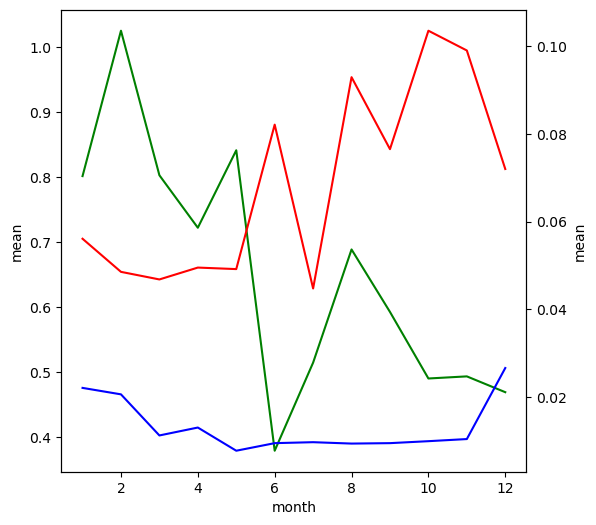

In [226]:
# Patterns
fig,ax=plt.subplots(figsize=(6,6))
sns.lineplot(x='month',y='mean',data=kjedahl_subset_plot,errorbar=('ci',.95),color='green',ax=ax)
ax1=ax.twinx()
sns.lineplot(x='month',y='mean',data=ammonia_subset_plot,errorbar=('ci',.95),color='red',ax=ax1)
sns.lineplot(x='month',y='mean',data=nitrate_subset_plot,errorbar=('ci',.95),color='blue',ax=ax1)

#### Processing Full Nitrate Dataset

In [227]:
hbconcat=hbwq[['DataSourceName','StationID','Latitude','Longitude','SampleDate','SampleTime','Characteristic','ResultUnit','ResultValue','WaterbodyName']]
hbconcat.head(3)

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
0,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Fluorides,mg/l,1.0,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Fecal Coliform,cfu/100ml,10.0,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Dissolved Solids,mg/l,27200.0,Hillsborough Bay


In [228]:
# Daily sample times are not relevant. setting to constant to avoid bad aggregations
mtbwq['SampleTime']='0:00:00'

In [229]:
mtbwq.head(1)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Latitude,Longitude,DEP_WBID,SampleDate,...,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit,SampleTime
0,20007,Middle Tampa Bay,USGS_NWIS,274237082325800,10F TAMPA BAY 11,"=""274237082325800""",27.710586,-82.549263,1558B,1972-07-10,...,Cl_mgl,Chloride,NaN,18000.0,NaN,NaN,NaN,18000,mg/l,0:00:00


In [230]:
# isolate features
mtbconcat=mtbwq[['DataSource','StationID','Latitude','Longitude','SampleDate','SampleTime','Characteristic','Result_Unit','Result_Value','WaterBodyName']]
mtbconcat.head(3)

,DataSource,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,Result_Unit,Result_Value,WaterBodyName
0,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,Chloride,NaN,18000.0,Middle Tampa Bay
1,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,"Nitrogen, ammonia as N",NaN,550.0,Middle Tampa Bay
2,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,"Nitrogen, ammonia as N",NaN,580.0,Middle Tampa Bay


In [231]:
# null check
mtbconcat.DataSource.isna().value_counts()

DataSource
False    544257
Name: count, dtype: int64

In [232]:
# rename units to match HB
mtbconcat.rename(columns={'WaterBodyName':'WaterbodyName','DataSource':'DataSourceName','Result_Unit':'ResultUnit','Result_Value':'ResultValue'},inplace=True)
mtbconcat.head(1)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\600712440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mtbconcat.rename(columns={'WaterBodyName':'WaterbodyName','DataSource':'DataSourceName','Result_Unit':'ResultUnit','Result_Value':'ResultValue'},inplace=True)


,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
0,USGS_NWIS,274237082325800,27.710586,-82.549263,1972-07-10,0:00:00,Chloride,NaN,18000.0,Middle Tampa Bay


In [233]:
# Union HB and MTB into 1 df
combwq=pd.concat([hbconcat,mtbconcat])
combwq.head(5)

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
0,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Fluorides,mg/l,1.00,Hillsborough Bay
1,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Fecal Coliform,cfu/100ml,10.00,Hillsborough Bay
2,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Dissolved Solids,mg/l,27200.00,Hillsborough Bay
3,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Dissolved oxygen saturation,percent (%),80.80,Hillsborough Bay
4,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-04-25,0:00:00,Dissolved oxygen (DO),mg/l,4.68,Hillsborough Bay


In [234]:
# check nitrogen compounds isolated
combwq[combwq.Characteristic.str.contains('Nit')==True].Characteristic.value_counts()

Characteristic
Nitrogen, Kjeldahl                                       44832
Nitrogen, ammonia as N                                   41417
Nitrogen                                                 35759
Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N             34215
Nitrogen, organic                                        31881
Nitrogen, Nitrate (NO3) as N                              5422
Nitrogen, ammonia (NH3) + ammonium (NH4)                  2157
Nitrogen, Nitrite (NO2) as N                               560
Nitrogen, Ammonium (NH4) as N                               28
Nitrogen, mixed forms (NH3)+(NH4)+organic+(NO2)+(NO3)       14
Nitrogen, ammonium (NH4) as N                                5
Name: count, dtype: int64

In [235]:
combwq.shape

(1592832, 10)

In [236]:
# Export data for processing outside of notebook
combwq.to_csv('NIT_FINAL.csv')

In [237]:
### There was one sampling station / service that was producing highly irregular nitrate values
### I suspect that they were correct - but there were so few measurements that, as significant outliers, it was better
### to remove them from the dataset. They were orders higher.

### Samples for this station from all datasets needs to be removed
combwq.drop(combwq[combwq.StationID=='560'].index,inplace=True)

In [238]:
#Checking to ensure iso of nitrates
combwq[combwq.Characteristic.str.lower().str.contains('nitra','nitri')==True]

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
18,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-03 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,5.000,Hillsborough Bay
81,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-10-10 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,4.000,Hillsborough Bay
89,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-03-06 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,32.000,Hillsborough Bay
116,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-02-14 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,14.000,Hillsborough Bay
159,FDEP Southwest Regional Operations Center,2.74734E+14,27.792639,-82.413861,2006-11-07 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,8.000,Hillsborough Bay
...,...,...,...,...,...,...,...,...,...,...
544162,PINELLAS,E6,27.811150,-82.594590,2012-12-05 11:11:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",NaN,20.000,Middle Tampa Bay
544176,PINELLAS,E6,27.791200,-82.607350,2012-12-05 11:56:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",NaN,20.000,Middle Tampa Bay
544196,PINELLAS,E6,27.791200,-82.607350,2012-12-05 11:56:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",mg/l,0.020,Middle Tampa Bay
544236,WIN_21FLGW,59865,27.758901,-82.428693,2022-01-19 00:00:00,0:00:00,"Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N",ug/l,25.000,Middle Tampa Bay


In [239]:
combwq[combwq.Characteristic.str.lower().str.contains('nitra','nitri')==True].shape

(39588, 10)

In [240]:
# Isolate each compound of interest
nitrates=combwq[combwq.Characteristic.str.lower().str.contains('nitra','nitri')==True]
kjeldahl=combwq[combwq.Characteristic.str.lower().str.contains('kjel')==True]
ammonia=combwq[combwq.Characteristic.str.lower().str.contains('ammo')==True]

In [241]:
print(nitrates.shape)
print(kjeldahl.shape)
print(ammonia.shape)

(39588, 10)
(44774, 10)
(43553, 10)


In [242]:
# Select only mg/l units
nitrates_mg=nitrates[nitrates.ResultUnit=='mg/l']
kjeldahl_mg=kjeldahl[kjeldahl.ResultUnit=='mg/l']
ammonia_mg=ammonia[ammonia.ResultUnit=='mg/l']

In [243]:
# sample size reduced. Many rows were duplicates using the other measurement unit.
print(nitrates_mg.shape)
print(kjeldahl_mg.shape)
print(ammonia_mg.shape)

(19650, 10)
(22302, 10)
(22151, 10)


In [244]:
# drop null values. Not imputing anything yet
nitrates_mg.dropna(inplace=True)
kjeldahl_mg.dropna(inplace=True)
ammonia_mg.dropna(inplace=True)
print(nitrates_mg.shape)
print(kjeldahl_mg.shape)
print(ammonia_mg.shape)

(19527, 10)
(22291, 10)
(22074, 10)


C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\1778963100.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nitrates_mg.dropna(inplace=True)
C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\1778963100.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kjeldahl_mg.dropna(inplace=True)
C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\1778963100.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ammonia_mg.dropna(inplace=True)


In [245]:
nitrates_mg.ResultValue.isna().value_counts()

ResultValue
False    19527
Name: count, dtype: int64

In [246]:
ammonia_mg.ResultValue.isna().value_counts()

ResultValue
False    22074
Name: count, dtype: int64

In [247]:
kjeldahl_mg.ResultValue.isna().value_counts()

ResultValue
False    22291
Name: count, dtype: int64

In [248]:
# Checking for outliers
ammoniasub[ammoniasub.ResultValue>2]

,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month,year,day,DateMonth


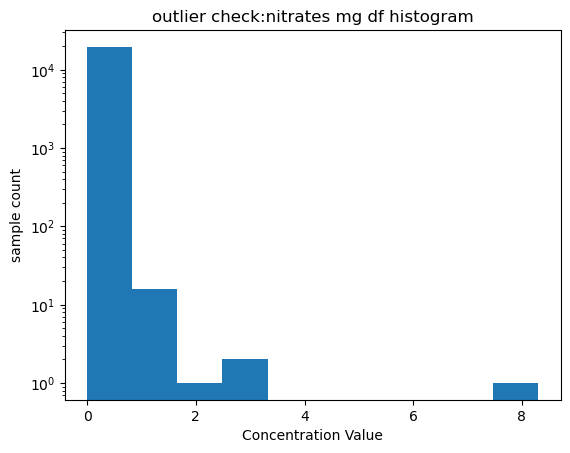

In [249]:
# distribution checks. log scale
plt.hist(nitrates_mg.ResultValue)
plt.yscale('log')
plt.ylabel('sample count')
plt.xlabel('Concentration Value')
plt.title('outlier check:nitrates mg df histogram')
plt.show()

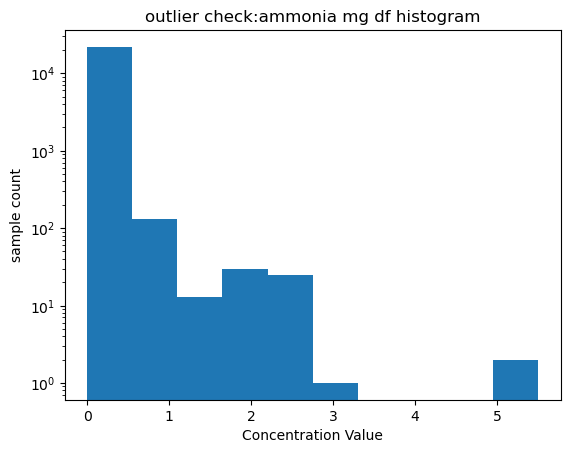

In [250]:
# distribution checks. log scale

plt.hist(ammonia_mg.ResultValue)
plt.yscale('log')
plt.ylabel('sample count')
plt.xlabel('Concentration Value')
plt.title('outlier check:ammonia mg df histogram')
plt.show()

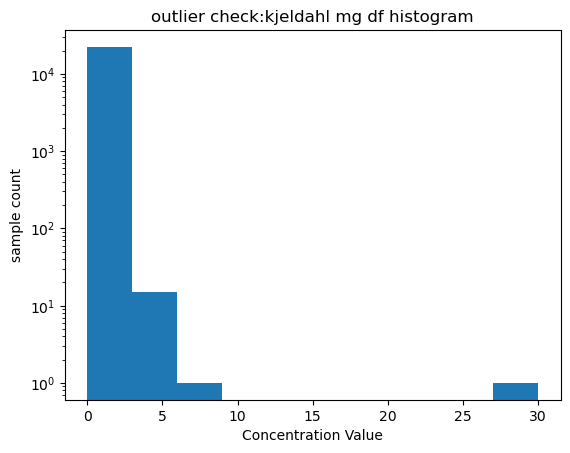

In [251]:
# distribution checks. log scale

plt.hist(kjeldahl_mg.ResultValue)
plt.yscale('log')
plt.ylabel('sample count')
plt.xlabel('Concentration Value')
plt.title('outlier check:kjeldahl mg df histogram')
plt.show()

In [252]:
## This value will get removed when the dataset time period is reduced
kjeldahl_mg[kjeldahl_mg.ResultValue>10]

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName
205105,LEGACYSTORET_21FLA,24020904,27.812694,-82.484278,1975-05-28,0:00:00,"Nitrogen, Kjeldahl",mg/l,30.0,Middle Tampa Bay


In [253]:
nitrates_mg_temp=nitrates_mg.reset_index()
#nitrates_mg[nitrates_mg.ResultValue>3].reset_index()
nit_iloc=nitrates_mg_temp[nitrates_mg_temp.ResultValue>2.5].index
for i in nit_iloc:
    nitrates_mg.iloc[i,-2]=nitrates_mg.iloc[i,-2]/1000

In [254]:
# standardize units
kjeldahl_mg['month']=kjeldahl_mg.SampleDate.dt.month
ammonia_mg['month']=ammonia_mg.SampleDate.dt.month
nitrates_mg['month']=nitrates_mg.SampleDate.dt.month

C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\666384419.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kjeldahl_mg['month']=kjeldahl_mg.SampleDate.dt.month
C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\666384419.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ammonia_mg['month']=ammonia_mg.SampleDate.dt.month
C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\666384419.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

In [255]:
# Isolate features of interest
kjeldahlsub=kjeldahl_mg[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude','month']]
ammoniasub=ammonia_mg[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude','month']]
nitratesub=nitrates_mg[['DataSourceName','StationID','SampleDate','SampleTime','ResultValue','ResultUnit','Latitude','Longitude','month']]

In [256]:
# Using a temp table to work around coding errors
# Looking at outlier data. Assess whether unit conv was issue
index_amm_temp=ammoniasub[ammoniasub.ResultValue>3].index
ammoniasub.loc[index_amm_temp].ResultValue=ammoniasub.loc[index_amm_temp].ResultValue/1000

In [257]:
# station suspected culprit for outlier values
kjeldahl_mg[kjeldahl_mg.StationID=='560']

,DataSourceName,StationID,Latitude,Longitude,SampleDate,SampleTime,Characteristic,ResultUnit,ResultValue,WaterbodyName,month


In [258]:
# create year col
kjeldahlsub['year']=kjeldahlsub.SampleDate.dt.year
ammoniasub['year']=ammoniasub.SampleDate.dt.year
nitratesub['year']=nitratesub.SampleDate.dt.year

C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\742156538.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kjeldahlsub['year']=kjeldahlsub.SampleDate.dt.year
C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\742156538.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ammoniasub['year']=ammoniasub.SampleDate.dt.year
C:\Users\Ajax\AppData\Local\Temp\ipykernel_84184\742156538.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

In [259]:
# creating a col that sets all months to a starting day of 1
kjeldahlsub['day']=1
ammoniasub['day']=1
nitratesub['day']=1

In [260]:
# format dt
kjeldahlsub['DateMonth']=pd.to_datetime(kjeldahlsub.astype(str).month+'-'+kjeldahlsub.astype(str).day+'-'+kjeldahlsub.astype(str).year)
ammoniasub['DateMonth']=pd.to_datetime(ammoniasub.astype(str).month+'-'+ammoniasub.astype(str).day+'-'+ammoniasub.astype(str).year)
nitratesub['DateMonth']=pd.to_datetime(nitratesub.astype(str).month+'-'+nitratesub.astype(str).day+'-'+nitratesub.astype(str).year)

In [261]:
# isolate dataset to years of interest in the study
kjeldahlsub=kjeldahlsub[kjeldahlsub.year>1989]
nitratesub=nitratesub[nitratesub.year>1989]
ammoniasub=ammoniasub[ammoniasub.year>1989]

In [262]:
# create better date column
nitratesub.SampleDate=pd.to_datetime(nitratesub.SampleDate.astype(str).str.slice(0,10))
kjeldahlsub.SampleDate=pd.to_datetime(kjeldahlsub.SampleDate.astype(str).str.slice(0,10))
ammoniasub.SampleDate=pd.to_datetime(ammoniasub.SampleDate.astype(str).str.slice(0,10))

In [263]:
#outlier check
kjeldahlsub[kjeldahlsub.ResultValue>4]

,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month,year,day,DateMonth
168160,Tampa Bay Water,M34,2009-07-27,0:00:00,6.2000,mg/l,27.928000,-82.415000,7,2009,1,2009-07-01
425580,EPC Monthly Routine Water Monitoring,70,1994-10-11,11:05:00,4.1300,mg/l,27.908899,-82.463203,10,1994,1,1994-10-01
439741,EPC Water Quality Data,70,1994-10-11,0:00:00,4.1300,mg/l,27.908888,-82.463055,10,1994,1,1994-10-01
86822,EPC_ROUTINE_MONITORING,136,2003-08-13,0:00:00,4.0600,mg/l,27.680000,-82.499199,8,2003,1,2003-08-01
100452,HCEPC_WQ,136,2003-08-13,0:00:00,4.0600,mg/l,27.680000,-82.499200,8,2003,1,2003-08-01
191363,HCEPC_WQ,19,1998-06-23,0:00:00,4.9357,mg/l,27.693300,-82.555800,6,1998,1,1998-06-01
310031,EPC_ROUTINE_MONITORING,19,1998-06-23,0:00:00,4.9400,mg/l,27.693399,-82.555901,6,1998,1,1998-06-01


**Only Kjeldahl in the filtered dataset follow a normal distribution, whereas Nitrates and Ammonia are heavily right-skew**
<br>

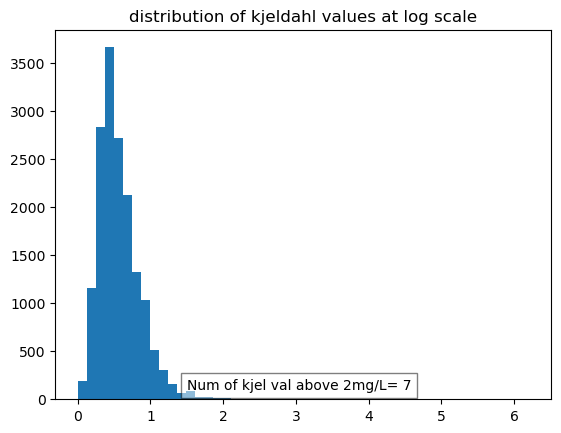

In [264]:
### Only Kjeldahl has a normal distribution

plt.hist(kjeldahlsub.ResultValue,bins=50)
#"plt.yscale('log')
plt.title('distribution of kjeldahl values at log scale')
plt.text(1.5, 100, f'Num of kjel val above 2mg/L= {kjeldahlsub[kjeldahlsub.ResultValue>4].ResultValue.count()}', bbox=dict(facecolor='white', alpha=0.5))
plt.show()

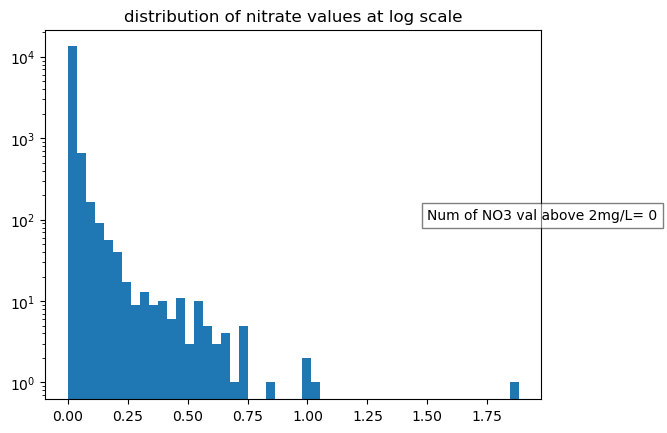

In [265]:
plt.hist(nitratesub.ResultValue,bins=50)
plt.yscale('log')
plt.title('distribution of nitrate values at log scale')
plt.text(1.5, 100, f'Num of NO3 val above 2mg/L= {nitratesub[nitratesub.ResultValue>2].ResultValue.count()}', bbox=dict(facecolor='white', alpha=0.5))
plt.show()

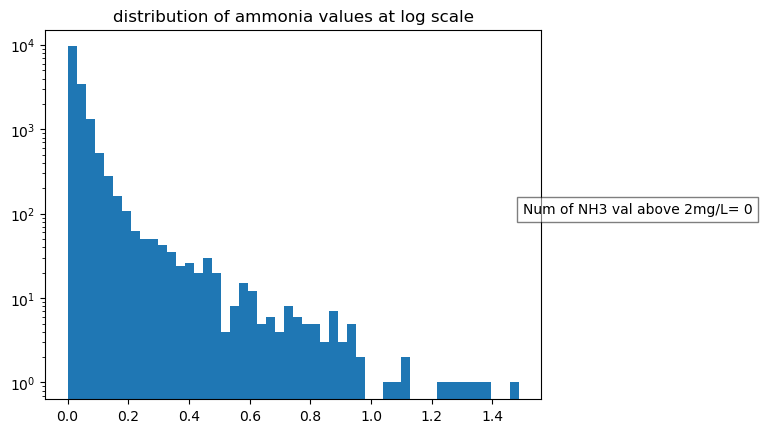

In [266]:
plt.hist(ammoniasub.ResultValue,bins=50)
plt.yscale('log')
plt.title('distribution of ammonia values at log scale')
plt.text(1.5, 100, f'Num of NH3 val above 2mg/L= {ammoniasub[ammoniasub.ResultValue>2].ResultValue.count()}', bbox=dict(facecolor='white', alpha=0.5))
plt.show()

In [267]:
# Setting checkpoint
ksub=kjeldahlsub.copy()
asub=ammoniasub.copy()
nsub=nitratesub.copy()

In [268]:
# Adding some columns to standardize dates and make next steps easier

ksub['week']=ksub.SampleDate.dt.isocalendar().week
asub['week']=asub.SampleDate.dt.isocalendar().week
nsub['week']=nsub.SampleDate.dt.isocalendar().week
ksub['adj_date']=pd.to_datetime(ksub['year'].astype(str) + '-W' + ksub['week'].astype(str) + '-1', format='%Y-W%W-%w')
asub['adj_date']=pd.to_datetime(asub['year'].astype(str) + '-W' + asub['week'].astype(str) + '-1', format='%Y-W%W-%w')
nsub['adj_date']=pd.to_datetime(nsub['year'].astype(str) + '-W' + nsub['week'].astype(str) + '-1', format='%Y-W%W-%w')
ksub.drop(columns='DateMonth',inplace=True)
asub.drop(columns='DateMonth',inplace=True)
nsub.drop(columns='DateMonth',inplace=True)
ksub.sort_values(by='SampleDate',inplace=True)
asub.sort_values(by='SampleDate',inplace=True)
nsub.sort_values(by='SampleDate',inplace=True)

In [269]:
# There are missing weeks that need to be imputed. This should be weekly data from 1990-2024
# Creating a df with all weeks, including missing values. Will outer join all nitrate groups, remove duplicates, impute or interpolate missing values
data = []
for year in range(1990, 2025):  # 24 years from 1990 to 2024
    for week in range(1, 53):  # Weeks 1 to 52
        data.append([year, week])
weekly=pd.DataFrame(data=data,columns=['year','week'])
weekly['adj_date']=pd.to_datetime(weekly['year'].astype(str) + '-W' + weekly['week'].astype(str) + '-1', format='%Y-W%W-%w')
print(len(data))
print(len(weekly))
print(weekly.min())
weekly.max()

1820
1820
year                       1990
week                          1
adj_date    1990-01-01 00:00:00
dtype: object


year                       2024
week                         52
adj_date    2024-12-23 00:00:00
dtype: object

In [270]:
# Make sure the datasets are as clean as possible (missing values dealt with later)
ksub.drop_duplicates(inplace=True)
asub.drop_duplicates(inplace=True)
nsub.drop_duplicates(inplace=True)

print(ksub.shape)
print(asub.shape)
print(nsub.shape)

(16150, 13)
(15779, 13)
(14303, 13)


In [271]:
# outer join kjeldahl df, no loss of data
test=weekly.merge(ksub,left_on=weekly.adj_date,right_on=ksub.adj_date,how='outer',suffixes=('_dt','_K'))

In [272]:
# adj_date_dt remains complete, dropping key_0
test.info()
test.drop(columns='key_0',inplace=True)
test.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16402 entries, 0 to 16401
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   key_0           16402 non-null  datetime64[ns]
 1   year_dt         16402 non-null  int64         
 2   week_dt         16402 non-null  int64         
 3   adj_date_dt     16402 non-null  datetime64[ns]
 4   DataSourceName  16150 non-null  object        
 5   StationID       16150 non-null  object        
 6   SampleDate      16150 non-null  datetime64[ns]
 7   SampleTime      16150 non-null  object        
 8   ResultValue     16150 non-null  float64       
 9   ResultUnit      16150 non-null  object        
 10  Latitude        16150 non-null  float64       
 11  Longitude       16150 non-null  float64       
 12  month           16150 non-null  float64       
 13  year_K          16150 non-null  float64       
 14  day             16150 non-null  float64       
 15  we

,year_dt,week_dt,adj_date_dt,DataSourceName,StationID,SampleDate,SampleTime,ResultValue,ResultUnit,Latitude,Longitude,month,year_K,day,week_K,adj_date_K
0,1990,1,1990-01-01,HCEPC_WQ,32,1990-01-03,0:00:00,0.54,mg/l,27.7931,-82.5706,1.0,1990.0,1.0,1,1990-01-01
1,1990,1,1990-01-01,HCEPC_WQ,13,1990-01-03,0:00:00,0.53,mg/l,27.8117,-82.5231,1.0,1990.0,1.0,1,1990-01-01


In [273]:
# outer join ammonia results, no loss of data
# all units are standardized to mg/l
# need to keep key_0 as it's the only complete date column.
test2=test.merge(asub['ResultValue'],left_on=[test.adj_date_dt,test.DataSourceName,test.StationID],right_on=[asub.adj_date,asub.DataSourceName,asub.StationID],how='outer',suffixes=('_dt','_A')).drop_duplicates()
test2.rename(columns={'key_0':'adj_date'},inplace=True)
test2.drop(columns=['key_1','key_2'],inplace=True)

In [274]:
# outer join nitrate results, no loss of data
# all units are standardized to mg/l
# last merge

test3=test2.merge(nsub['ResultValue'],left_on=[test2.adj_date,test2.DataSourceName,test2.StationID],right_on=[nsub.adj_date,nsub.DataSourceName,nsub.StationID],how='outer',suffixes=('_dt','_N')).drop_duplicates()

In [275]:
test3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22461 entries, 0 to 25146
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   key_0           22461 non-null  datetime64[ns]
 1   key_1           20886 non-null  object        
 2   key_2           20886 non-null  object        
 3   adj_date        20439 non-null  datetime64[ns]
 4   year_dt         19116 non-null  float64       
 5   week_dt         19116 non-null  float64       
 6   adj_date_dt     19116 non-null  datetime64[ns]
 7   DataSourceName  18864 non-null  object        
 8   StationID       18864 non-null  object        
 9   SampleDate      18864 non-null  datetime64[ns]
 10  SampleTime      18864 non-null  object        
 11  ResultValue_dt  18864 non-null  float64       
 12  ResultUnit      18864 non-null  object        
 13  Latitude        18864 non-null  float64       
 14  Longitude       18864 non-null  float64       
 15  month  

In [276]:
# Isolate columns of interest
nmerge_stage=test3[test3.columns[[0,7,13,14,11,20,21]]]

In [277]:
nmerge_stage.head(1)

,key_0,DataSourceName,Latitude,Longitude,ResultValue_dt,ResultValue_A,ResultValue
0,1990-01-01,EPC_ROUTINE_MONITORING,27.8118,-82.523201,0.53,0.04,0.003


In [278]:
# Rename columns

nmerge_stage.columns=['date_adj','DataSourcveName','Lat','Long','ResultValue_K','ResultValue_A','ResultValue_N']
print(nmerge_stage.shape)
nmerge_stage.head(2)

(22461, 7)


,date_adj,DataSourcveName,Lat,Long,ResultValue_K,ResultValue_A,ResultValue_N
0,1990-01-01,EPC_ROUTINE_MONITORING,27.8118,-82.523201,0.53,0.04,0.003
1,1990-01-01,EPC_ROUTINE_MONITORING,27.7932,-82.570701,0.54,0.03,0.003


In [279]:
# Establish independent copy of merged base table
nmerge_base=nmerge_stage.copy()

In [280]:
nmerge_base[nmerge_base.ResultValue_N>2]

,date_adj,DataSourcveName,Lat,Long,ResultValue_K,ResultValue_A,ResultValue_N


In [281]:
# Aggregate at weekly date intervals
nmerge_stage2=nmerge_stage.groupby('date_adj').agg({
    'ResultValue_K':'mean',
    'ResultValue_A':'mean',
    'ResultValue_N':'mean'
})

In [282]:
# Extra weeks beyond the end of the dataset (8/26/24)
# Cut out extra weeks
# Check for nulls
nmerge_stage3=nmerge_stage2.iloc[:-17,:]
nmerge_stage3.isna().sum()

ResultValue_K    235
ResultValue_A    246
ResultValue_N    248
dtype: int64

There are fewer missing values than expected! That's good, interpolation shouldn't be a problem. <br>
Seasonality shouldn't be expected for periods less than a month. <br>
Interpolation with 2 period in both directions should give best approximation of values.<br>

In [283]:
nmerge=nmerge_stage3.interpolate(method='linear', limit_direction='both', limit=2)

In [284]:
print(f'{nmerge.info()}\n\n\nSHAPE:\n{nmerge.shape}\n\n\n\nDESCRIBE:\n{nmerge.describe()}')
nmerge.head(2)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1803 entries, 1990-01-01 to 2024-08-26
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ResultValue_K  1803 non-null   float64
 1   ResultValue_A  1803 non-null   float64
 2   ResultValue_N  1803 non-null   float64
dtypes: float64(3)
memory usage: 56.3 KB
None


SHAPE:
(1803, 3)



DESCRIBE:
       ResultValue_K  ResultValue_A  ResultValue_N
count    1803.000000    1803.000000    1803.000000
mean        0.575472       0.055545       0.023528
std         0.298930       0.084185       0.033887
min         0.060000       0.000000       0.000000
25%         0.383333       0.018134       0.007000
50%         0.511389       0.030000       0.013895
75%         0.704722       0.056324       0.024015
max         3.030000       1.028308       0.430000


,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826


In [285]:
print(f'nmerge shape:\n {nmerge.shape}\n')
print(f'######\n\nMerge1 duplicates: \n{nmerge.duplicated().value_counts}\n\n######\nResultAction:')
if nmerge.duplicated().any():
    print('True.Duplicates, drop\n')
    nmerge.drop_duplicates(inplace=True)
else:
    print('False. No Duplicates, no drop\n')
print(f'######\n\nNulls:\n{nmerge.isna().sum()}\n')
print(f'######\nnew shape:{nmerge.shape}')
if nmerge.columns[0]=='key_0':
    print('Newly created key columns not dropped\nColumns now dropped')
    nmerge.drop(columns=nmerge.columns[[0,1,2]],inplace=True)
else:
    print('Columns not dropped')
nmerge.head(3)


nmerge shape:
 (1803, 3)

######

Merge1 duplicates: 
<bound method IndexOpsMixin.value_counts of date_adj
1990-01-01    False
1990-01-08    False
1990-01-15    False
1990-01-22    False
1990-01-29    False
              ...  
2024-07-29    False
2024-08-05    False
2024-08-12    False
2024-08-19    False
2024-08-26    False
Length: 1803, dtype: bool>

######
ResultAction:
False. No Duplicates, no drop

######

Nulls:
ResultValue_K    0
ResultValue_A    0
ResultValue_N    0
dtype: int64

######
new shape:(1803, 3)
Columns not dropped


,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826
1990-01-15,0.408333,0.071667,0.006500


In [286]:
# change directory for exporting of df
os.chdir('J:\\Brainstation\\BS Git\\human Imact\\Nutrient_loading')

In [287]:
ksub.to_csv('kjeldahl.csv')
nsub.to_csv('nitrate.csv')
asub.to_csv('ammonia.csv')
nmerge.to_csv('nit_merged_mean.csv')

In [ ]:
fig, ax = plt.subplots(figsize=(8,15))
ax1=ax.twinx()
plt.subplot(3,1,1)
nmerge.ResultValue_K.hist(color='g',label='Kjeldahl')
plt.subplot(3,1,2)
nmerge.ResultValue_A.hist(color='y',label='Ammonia')
plt.subplot(3,1,3)
nmerge.ResultValue_N.hist(color='r',label='Nitrate')
#plt.subplot(3,1,4)
plt.legend()
plt.suptitle('Distribution of Nitrogen Compounds Concentration Measurements')
plt.tight_layout()
plt.show()

In [ ]:
# fig,ax = plt.subplots(figsize=(8,8))

sns.lineplot(x=nmerge.index, y=nmerge.ResultValue_K, label='[Kjeldahl]',color='green',ax=ax)
#plt.xlabel*('Concentrations of Organic Nitrogen (Kjel)')
ax1=ax.twinx()
sns.lineplot(x=nmerge.index, y=nmerge.ResultValue_A, label='[Ammonia]',color='yellow',ax=ax1)
sns.lineplot(x=nmerge.index, y=nmerge.ResultValue_N, label='[Nitrates]',color='red',ax=ax1)
plt.title('Concentrations of Nitrogen compounds in Tampa Bay, 1990-2024')
plt.xlabel('Date')
plt.ylabel('Concentrations of Compounds (mg/l)')
plt.yscale('log')

In [ ]:
nmerge['K_moving_average'] = nmerge.ResultValue_K.rolling(window=36).mean()
nmerge['A_moving_average'] = nmerge.ResultValue_A.rolling(window=36).mean()
nmerge['N_moving_average'] = nmerge.ResultValue_N.rolling(window=36).mean()

In [ ]:
plt.figure(figsize=(7,7))
nmerge.ResultValue_K.plot(color='b')
nmerge.K_moving_average.plot(color='g',lw=4)
plt.yscale('log')
plt.show()

In [ ]:
plt.figure(figsize=(7,7))
nmerge.A_moving_average.plot(color='y',lw=4)
nmerge.N_moving_average.plot(color='r',lw=4)
plt.yscale('log')
plt.title('Log Scale Moving Average of Ammonia and Nitrate Nitrogen-compounds in Tampa Bay, 1990-2024')
plt.show()

Measurements of Nitrogen in Kjeldahl can be understood as measuerments of organic nitrogen found water systems.
Measurements of Ammonia (NH3/NH4+) can be understood as anthropogenic sources of nitrogen
Measurements of Nitrates/Nitrites are anthropogenic sources of nitrogen.

In order to use Ammonia and Nitrates as factors for the API while using Kjeldahl measurements as a feature of the marine ecosystem, it has to be shown that there's correlation between NH3,NO3 ~ Kjel.<br>

This study uses vector autoregression (VAR) to look at these relationships in a time series.

Sampling frequency, measurements have been standardized for frequency and units.<br>
Missing values have been interpolated. 

In [289]:
### nmerge df Checkpoint

#$nmerge_backup=nmerge.copy()
#nmerge=nmerge_back.copy()

In [290]:
nmerge.index

DatetimeIndex(['1990-01-01', '1990-01-08', '1990-01-15', '1990-01-22',
               '1990-01-29', '1990-02-05', '1990-02-12', '1990-02-19',
               '1990-02-26', '1990-03-05',
               ...
               '2024-06-24', '2024-07-01', '2024-07-08', '2024-07-15',
               '2024-07-22', '2024-07-29', '2024-08-05', '2024-08-12',
               '2024-08-19', '2024-08-26'],
              dtype='datetime64[ns]', name='date_adj', length=1803, freq=None)

In [291]:
nmergeK=pd.Series(nmerge.ResultValue_K)
nmergeK.index=nmerge.index

In [292]:
nmerge.iloc[:,:-3]

""
date_adj
1990-01-01
1990-01-08
1990-01-15
1990-01-22
1990-01-29
...
2024-07-29
2024-08-05
2024-08-12


In [293]:
nmerge.iloc[:,-3:].describe()

,ResultValue_K,ResultValue_A,ResultValue_N
count,1803.000000,1803.000000,1803.000000
mean,0.575472,0.055545,0.023528
std,0.298930,0.084185,0.033887
min,0.060000,0.000000,0.000000
25%,0.383333,0.018134,0.007000
50%,0.511389,0.030000,0.013895
75%,0.704722,0.056324,0.024015
max,3.030000,1.028308,0.430000


In [294]:
VAR_data=nmerge.iloc[:,0:3]
rolling_avg_data=nmerge.iloc[:,:-3]

In [2740]:
scaler1=MinMaxScaler()
scaler2=MinMaxScaler()
scaler1.fit(VAR_data)
VAR_scaled = pd.DataFrame(scaler1.transform(VAR_data), columns=VAR_data.columns, index=VAR_data.index)
scaler2.fit(rolling_avg_data)
rolling_scaled=pd.DataFrame(scaler2.transform(rolling_avg_data), columns=rolling_avg_data.columns, index=rolling_avg_data.index)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_53812\1829982694.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


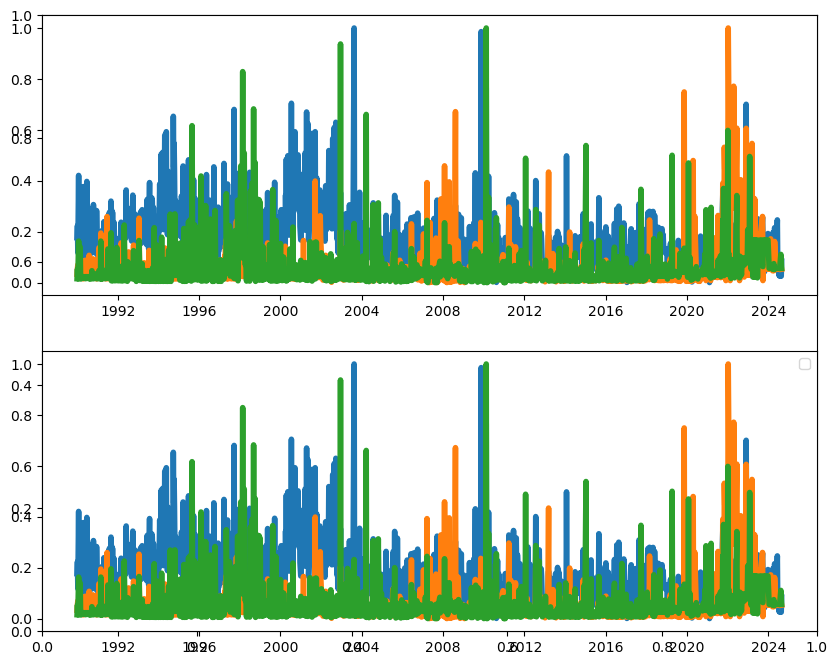

In [2741]:
plt.subplots(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(VAR_scaled,lw=4)
plt.subplot(2,1,2)
plt.plot(rolling_scaled,lw=4)
plt.legend()
plt.show()

In [2742]:
VAR_data.head(2)

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826


In [2743]:
train_data_scaled

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.175669,0.048281,0.015116
1990-01-08,0.222956,0.082332,0.053084
1990-01-15,0.116708,0.103805,0.015116
1990-01-22,0.268603,0.080871,0.088953
1990-01-29,0.420498,0.057937,0.162791
...,...,...,...
2014-03-10,0.013835,0.036211,0.006977
2014-03-17,0.085599,0.021051,0.006977
2014-03-24,0.160396,0.295481,0.086047


In [2744]:
test_data_scaled

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
2014-04-14,0.110307,0.098976,0.023256
2014-04-21,0.118999,0.065952,0.007442
2014-04-28,0.131084,0.089803,0.006977
2014-05-05,0.125974,0.063973,0.006977
2014-05-12,0.115248,0.008691,0.006977
...,...,...,...
2024-07-29,0.025129,0.095597,0.074074
2024-08-05,0.025977,0.112978,0.092334
2024-08-12,0.026826,0.130359,0.110594


### Modelling

#### Augmented Dickey-Fuller Test for Univariate Stationarity

_**Aug. Dickey-Fuller Test:**_
>Hypothesis-<br>
>**H<sub>0</sub>**: Individual nitrogen-compound features do not exhibit statistically significant stationarity <br>
>**H<sub>1</sub>**: Individual nitrogen-compound features do exhibit stationarity over time

In [298]:
# Data has already been scaled with MinMax

# Splits scaled data
train_data, test_data = train_test_split(VAR_data, test_size=0.3, shuffle=False)

# Scale data
scaler=MinMaxScaler()
scaler.fit(train_data)
train_data_scaled = pd.DataFrame(scaler.transform(train_data), columns=train_data.columns, index=train_data.index)
test_data_scaled = pd.DataFrame(scaler.transform(test_data), columns=test_data.columns, index=test_data.index) 

In [311]:
ADF_df=pd.DataFrame(columns=['feature','t_t_subset,'])

# Running ADF test
for i in train_data.columns:
    print(f'Unscaled Data:{i}\n{check_stationarity(VAR_data[i])}\n')
        
    print(f'TRAIN Feature:{i}\n{check_stationarity(train_data_scaled[i])}\n')
    print(f'TEST Feature:{i}\n{check_stationarity(test_data_scaled[i])}\n\n###############')

ADF Statistic: -3.256494
p-value: 0.016939
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
Unscaled Data:ResultValue_K
None

ADF Statistic: -3.506638
p-value: 0.007818
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
TRAIN Feature:ResultValue_K
None

ADF Statistic: -5.909698
p-value: 0.000000
Critical Values:
	1%: -3.443
	5%: -2.867
	10%: -2.570
TEST Feature:ResultValue_K
None

###############
ADF Statistic: -4.450749
p-value: 0.000241
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
Unscaled Data:ResultValue_A
None

ADF Statistic: -7.562957
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
TRAIN Feature:ResultValue_A
None

ADF Statistic: -2.380043
p-value: 0.147448
Critical Values:
	1%: -3.443
	5%: -2.867
	10%: -2.570
TEST Feature:ResultValue_A
None

###############
ADF Statistic: -7.503430
p-value: 0.000000
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
Unscaled Data:ResultValue_N
None

ADF Statistic: -7.326741
p-value: 0.000000
Critical V

When run with the original, full unscaled dataset, null hypothesis is rejected
- Scaled Train data demonstrates stationarity for all features.
- Test data instructs to reject the null hypothesis for Ammonia, both a high p-value and small ADF relative to critical values.<br>
ADF statistic < Critical Values(1%)<br><br>

Running VAR next.

#### Vector Auto Regression (VAR)

**Vector Autoregression**
>Hypothesis-<br>
>**H<sub>0</sub>**: Analysis, through coefficient comparison, predictive comparison and other insights, do not show any definitive differentiation of Kjeldahl values from Nitrates and Ammonia  <br>
>**H<sub>1</sub>**: VAR indicates that Kjeldahl values patterns over time vary significantly from that of _both_ ammonia and nitrates.

In [351]:
VAR_data

,ResultValue_K,ResultValue_A,ResultValue_N
date_adj,,,
1990-01-01,0.583333,0.033333,0.006500
1990-01-08,0.723684,0.056842,0.022826
1990-01-15,0.408333,0.071667,0.006500
1990-01-22,0.859167,0.055833,0.038250
1990-01-29,1.310000,0.040000,0.070000
...,...,...,...
2024-07-29,0.136519,0.066000,0.031852
2024-08-05,0.139037,0.078000,0.039704
2024-08-12,0.141556,0.090000,0.047556


In [352]:
# VAR Model
model = VAR(train_data_scaled)
model2 = VAR(VAR_scaled)
# Fit Scaled VAR Lasso
#results = model.fit(method='ols', alpha=0.1, L1_wt=1, lags=12) 
#results = model.fit(maxlags=12, ic='aic', trend='ct', seas=52)  

C:\Users\Ajax\miniconda3\envs\bs\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Ajax\miniconda3\envs\bs\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [353]:
results4=model.fit(maxlags=4,ic='aic')
results8=model.fit(maxlags=8,ic='aic')
results12=model.fit(maxlags=12,ic='aic')
results16=model.fit(maxlags=16,ic='aic')
results26=model.fit(maxlags=26,ic='aic')
results_whole4=model2.fit(maxlags=4,ic='aic')
results_whole12=model2.fit(maxlags=12,ic='aic')
results_whole26=model2.fit(maxlags=26,ic='aic')

In [354]:
# Print model 2 (whole data set...just to see) summary

# Results for lag=4
print(results4.summary())
print('4############################################')
# Results for lag=8
print(results8.summary())
print('8############################################')
# Results for lag=12
print(results12.summary())
print('12############################################')

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Dec, 2024
Time:                     23:30:35
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -15.2462
Nobs:                     1258.00    HQIC:                  -15.3456
Log likelihood:           4373.99    FPE:                2.03928e-07
AIC:                     -15.4055    Det(Omega_mle):     1.97734e-07
--------------------------------------------------------------------
Results for equation ResultValue_K
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.066458         0.007944            8.365           0.000
L1.ResultValue_K         0.191265         0.027675            6.911           0.000
L1.ResultValue_A        -0.012605       

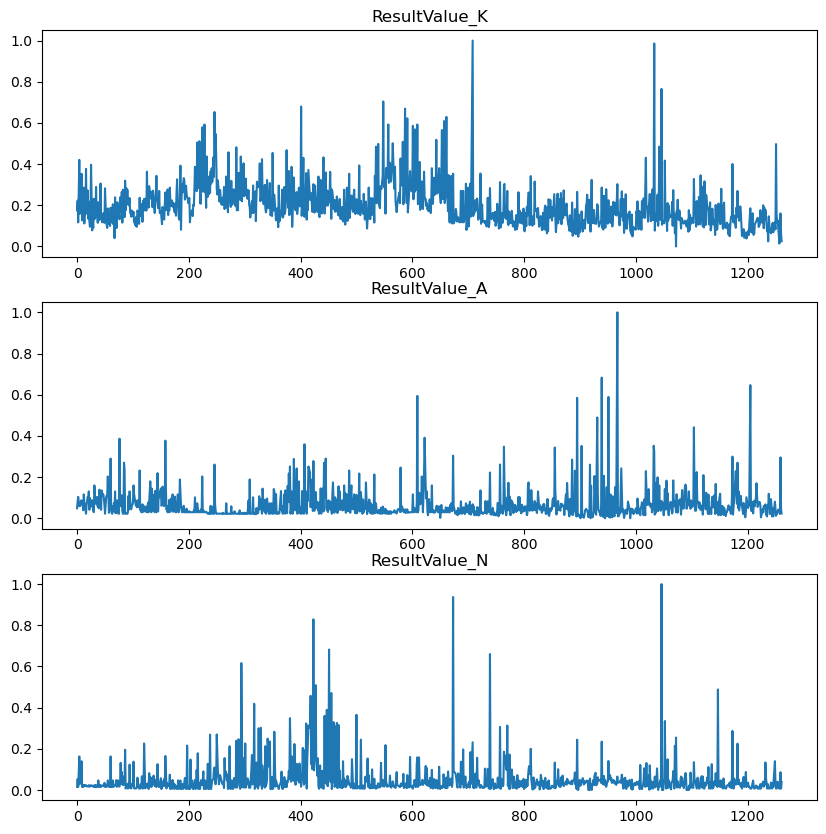

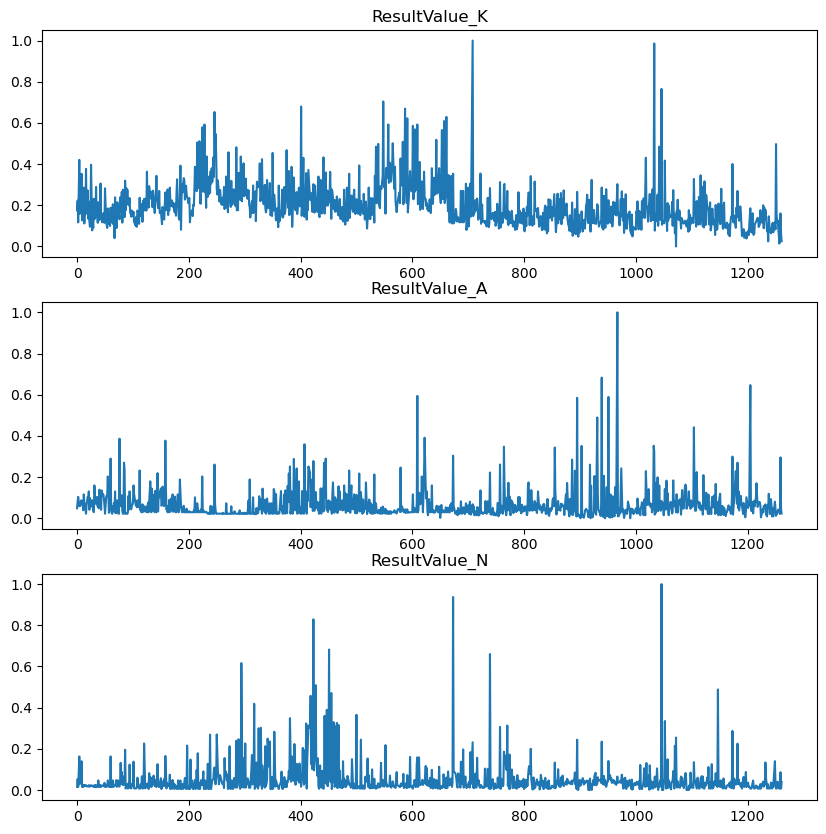

In [355]:
results4.plot()

In [356]:
lags = 12  
last_observations = train_data_scaled.values[-lags:]  
forecast = results12.forecast(y=last_observations, steps=len(test_data))

In [357]:
# Create a DataFrame with actual and forecasted values
forecast_df = pd.DataFrame({
    'Actual_K': test_data['ResultValue_K'],
    'Forecast_K': forecast[:, 0],  # Assuming Kjeldahl is the first variable
    'Actual_A': test_data['ResultValue_A'],
    'Forecast_A': forecast[:, 1],  # Assuming ammonia is the second variable
    'Actual_N': test_data['ResultValue_N'],
    'Forecast_N': forecast[:, 2]   # Assuming nitrates is the third variable
}, index=test_data.index)

# Calculate error metrics (example with MAE)
from sklearn.metrics import mean_absolute_error
mae_k = mean_absolute_error(forecast_df['Actual_K'], forecast_df['Forecast_K'])


In [358]:
forecast_df

,Actual_K,Forecast_K,Actual_A,Forecast_A,Actual_N,Forecast_N
date_adj,,,,,,
2014-04-14,0.389333,0.100525,0.068333,0.060467,0.010000,0.029688
2014-04-21,0.415133,0.125225,0.045533,0.085827,0.003200,0.041224
2014-04-28,0.451000,0.104318,0.062000,0.078892,0.003000,0.024224
2014-05-05,0.435833,0.076291,0.044167,0.063757,0.003000,0.036755
2014-05-12,0.404000,0.097401,0.006000,0.074987,0.003000,0.028698
...,...,...,...,...,...,...
2024-07-29,0.136519,0.193407,0.066000,0.067237,0.031852,0.051426
2024-08-05,0.139037,0.193407,0.078000,0.067237,0.039704,0.051426
2024-08-12,0.141556,0.193407,0.090000,0.067237,0.047556,0.051426


In [359]:
### Results of the model without forecasting
results.plot()

NameError: name 'results' is not defined

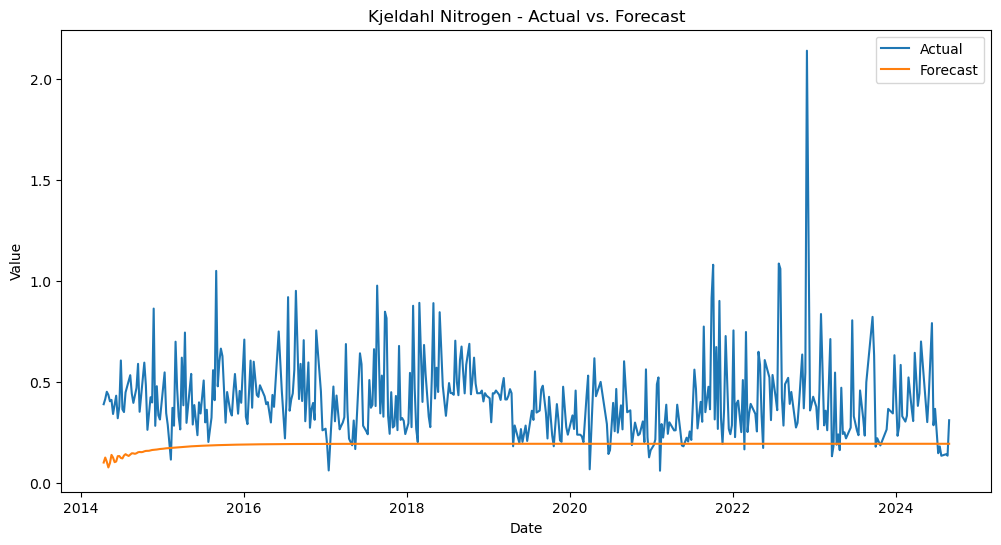

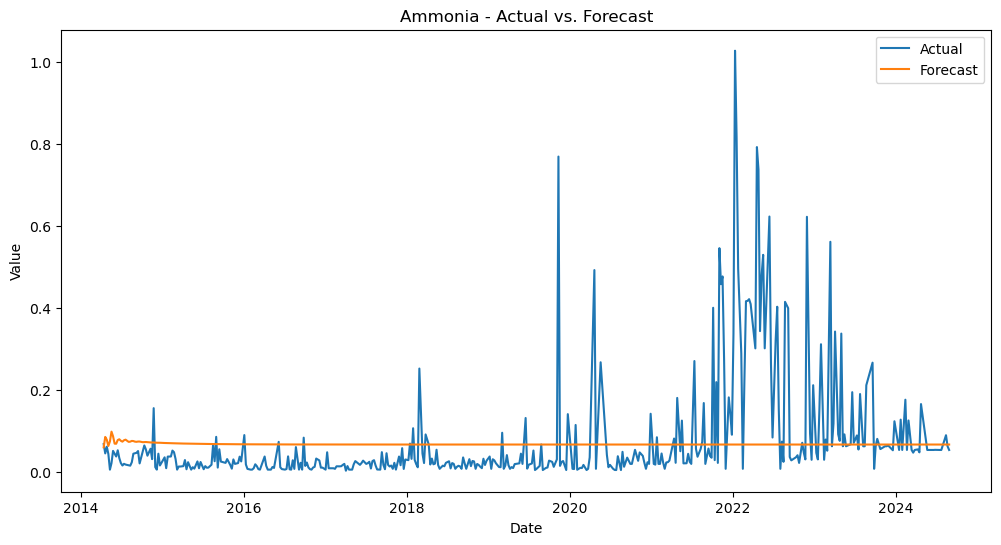

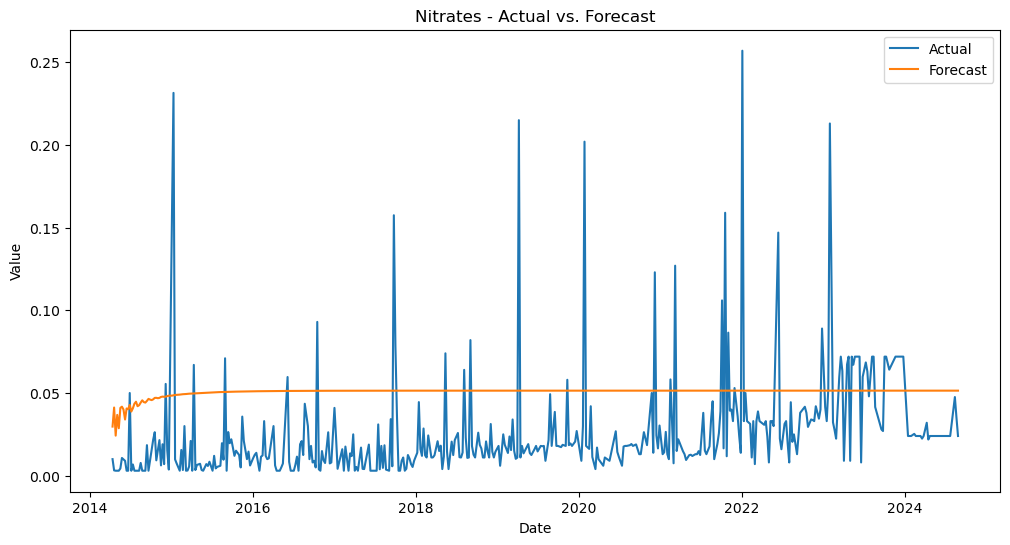

In [360]:
# Plot the actual vs. forecasted values for Kjeldahl
# The model shows barely any sign of seasonality in the first few forecasted periods before reaching a plateau, where it remains for the rest of the time series.

plt.figure(figsize=(12, 6))
plt.plot(forecast_df['Actual_K'], label='Actual')
plt.plot(forecast_df['Forecast_K'], label='Forecast')
plt.title('Kjeldahl Nitrogen - Actual vs. Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Repeat the plotting for ammonia and nitrates
plt.figure(figsize=(12, 6))
plt.plot(forecast_df['Actual_A'], label='Actual')
plt.plot(forecast_df['Forecast_A'], label='Forecast')
plt.title('Ammonia - Actual vs. Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(forecast_df['Actual_N'], label='Actual')
plt.plot(forecast_df['Forecast_N'], label='Forecast')
plt.title('Nitrates - Actual vs. Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'K_moving_average'

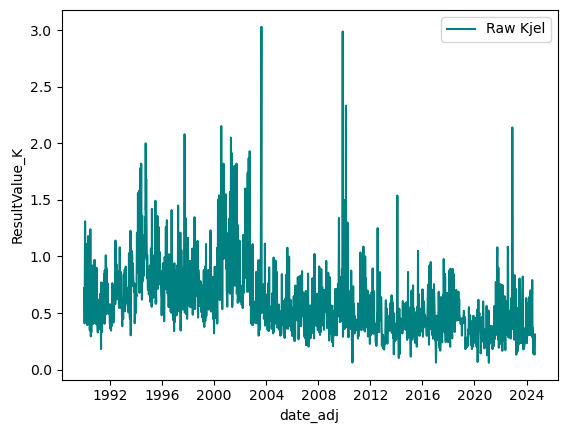

In [361]:
sns.lineplot(x=nmerge.index,y=nmerge.ResultValue_K,label='Raw Kjel',color='teal')
sns.lineplot(x=nmerge.index,y=nmerge.K_moving_average,label='Mov. Avg. Kjel',color='red')
plt.title('Kjeldahl 1990-2024, Raw and Moving Average')
plt.show()

AttributeError: 'DataFrame' object has no attribute 'K_moving_average'

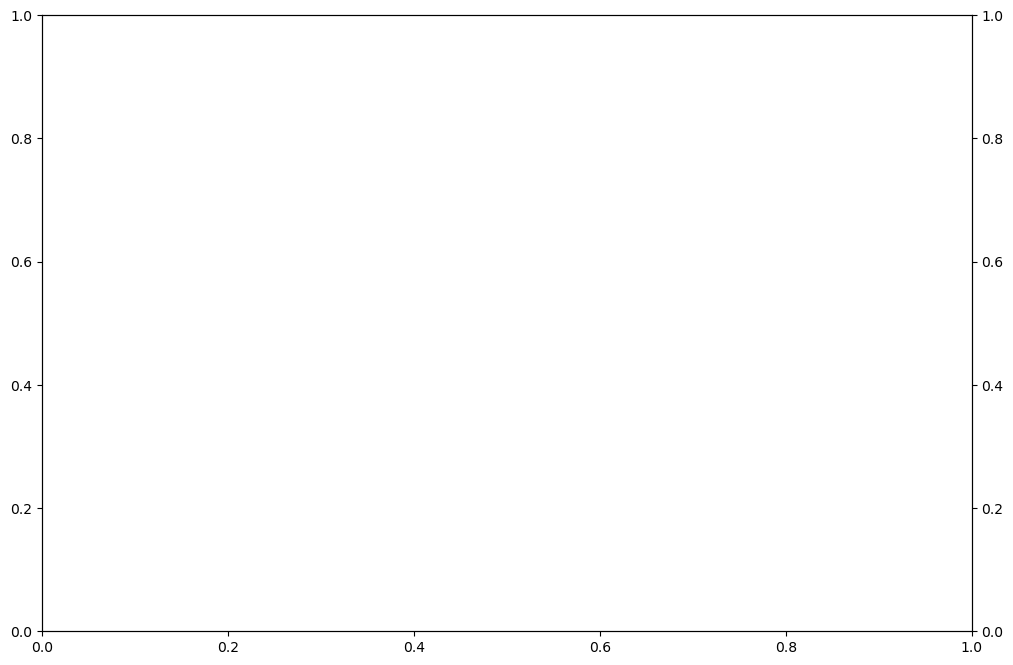

In [362]:
fig,ax = plt.subplots(figsize=(12,8))
#sns.lineplot(x=nmerge.index,y=nmerge.ResultValue_A,label='Raw Ammonia',color='black',lw=1,ax=ax)
ax1=ax.twinx()
#sns.lineplot(x=nmerge.index,y=nmerge.ResultValue_N,label='Raw Nitrates',color='orange',lw=1,ax=ax1)
sns.lineplot(x=nmerge.index,y=nmerge.K_moving_average,label='Mov. Avg. Kjel',color='teal',ax=ax)
sns.lineplot(x=nmerge.index,y=nmerge.A_moving_average,label='Mov. Avg. Ammonia',color='red',lw=4,ax=ax1)
sns.lineplot(x=nmerge.index,y=nmerge.N_moving_average,label='Mov. Avg. Nitrates',color='orange',lw=4,ax=ax1)


plt.title('Nitrates/Ammonia 1990-2024, Raw and Moving Average')
plt.show()

__** This test was ultimately disregarded. Exported CSVs were imported in the NEKTON notebook for further processing **__

### Nitrogen Loading Conclusions

Due to issues with formatting the datetime index, I haven't been able to get the frequency to set properly and, consequently, forecasting likely will be unhelpful. Results and conclusions drawn from the model should be understood with this in mind as it's difficult to assess the accuracy and performance of the model, particularly as a forecasting model. There are inferences that can be drawn about the relationships captured by the model between the 3 features.

The model had the most difficulty handling Nitrate values. P-values were less than 0.05 only in 4 lag iterations of the model - spiking beyond 0.45 in the next tier of 8 lags. The results do show, however, in the 4 and subsequent 8 lag iterations, nitrates has strong autocorrelation at the 4 week intervals (L1,L4,L8) which may provide insight into its sources. The 4 week lag period could be related to the transport time of nitrates through the watershed, which begins far inland before draining into the river systems and ultimately the bay. Monthly cyclicality of anthrogenic comunity services - such as agricultral practices, sewage treatment, would correlate  

There is some noted influence of ammonia on Kjeldahl values at lag 1 and lag 4, which could be explained by the conversion of organic nitrates into ammonia in the mineralisation process. The Kjelahl method also is measured as ammonia measured while processing water samples with a catalyst agent. Indirect influences of biological processes and existing levels of ammonia could explain this relationship; however, this is only one observation and not the primary driver of Kjeldahl concentrations or vice-versa.

Kjeldahl is more complex with of autocorrelation at lag 1,2,8,9, influences on ammonia at lag 1,2,4 and nitrogen  while also impacting ammonia at week 1,2,4, and nitro at possible 1 and 2; however, this does lend confidence to its use as a proxy as the organic form of nitrogen in the ecosystem. Decay and decomposition would impact ammonia and nitrate concentrations.

Low values of AIC and BIC are encouraging that the model performed reasonably well in explaining the existing data; however, no conclusions can be made about the model's predictive power without being rerun with corrected datasets and evaluation of its performance through error metrics.

I am confident though in proceeding with the base assumptions necessary to proceed its application in the development of the API (index).

## Development

This section introduces development data of Tampa Bay, stretching from 1990-2024.

Initially, this study proposed looking at waterfront properties; the full property record dataset was used for 2 reasons. 1- Quantity of Data. Annual figures for construction would have been too low. More importantly, because of the size of the watershed (extending beyond county lines),  fertilizers, sewage treatment and other anth.gen. substances can be traced far inland. These compounds have been shown to be the most damaging to the Tampa Bay ecosystem. Input from increased activity, development and subsequent contamination of the water that feeds the bay should be evaluated by development at greater resolution. These have an equal weighted influence on anthropogenic pressures on the local marine ecosystem.

During the EDA phase, it became clear through the analysis of nutrient data that consideration of specific construction data had to be expanded further inland that initially expect.
The depth of the watersheds of Tampa Bay, its reach inland and the requirement to extend the reach of the study of nutrient loading into the bay also necessitated expansion of construction and regional population growth.

Consequently, a larger data set was used to estimate the impact of development pressures.

Property records, sales, changes in land use and construction data were aggregated.
For the purposes of the initial phase of this study, annual construction was used as the proxy for coastal development.
The priamry feature of interest was total construction, additional important information has been aggregated for further analysis after the implementation of the API.
These sum of features include:
- Property Acreage
- Year Built
- Number of structures built
- Land type
- Total square footage of structure

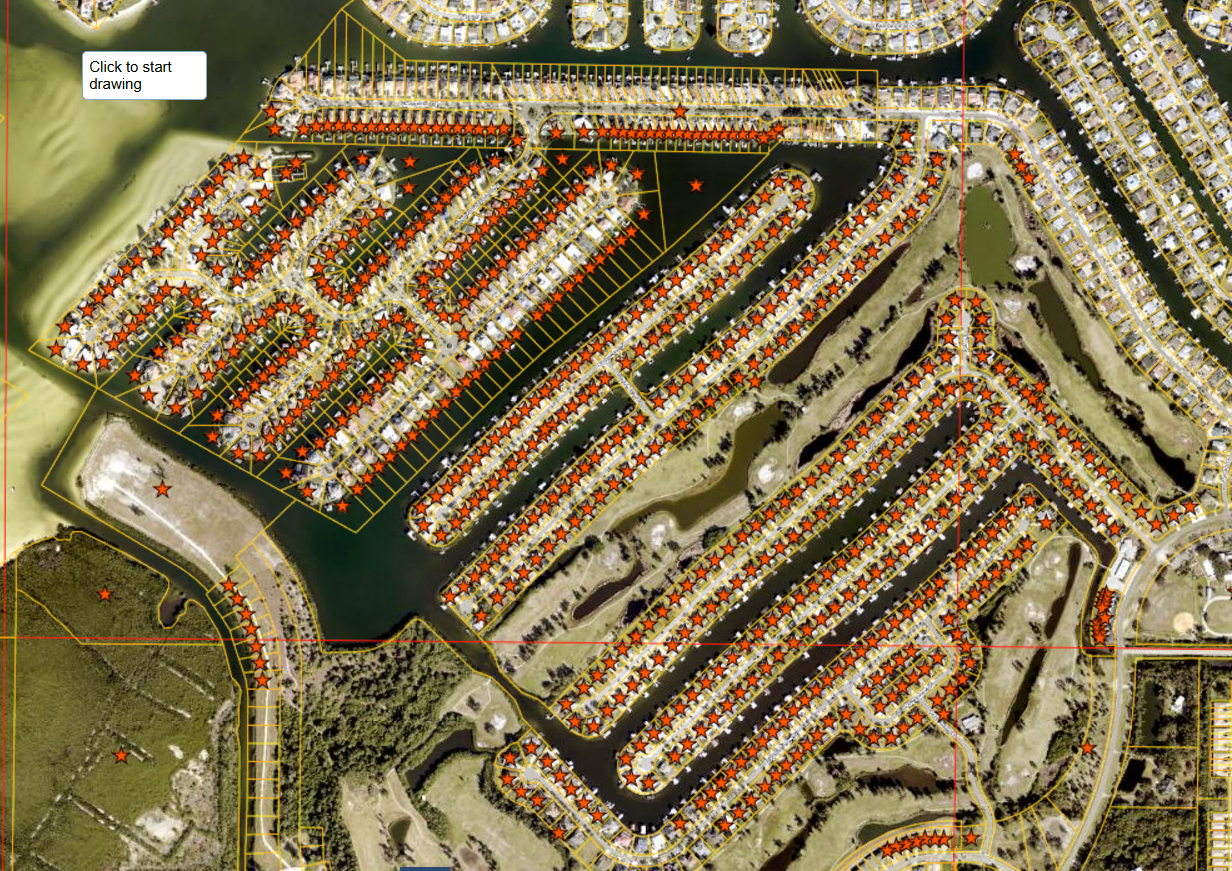

In [530]:
# Introduce base table with property records.
# Data read in at start of notebook
# 'proprx' 'Property Recorsd'

In [531]:
proprx

,FOLIO,TYPE,Edit_dt,PIN,DOR_C,OWNER,ADDR_1,ADDR_2,CITY,STATE,...,MUNI,SD1,SD2,TIF,BASE,S_DATE,VI,S_AMT,ACREAGE,NBHC
0,1.000000e+04,NaN,4/8/2019,A-23-33-15-ZZZ-000000-00020.0,8800,UNITED STATES,EGMONT KEY STATE PARK,4905 34TH ST S PMB 5000,SAINT PETERSBURG,FL,...,A,NaN,NaN,NaN,0,NaN,NaN,0.0,313.011000,227002.0
1,5.000000e+04,NaN,4/8/2019,A-23-33-15-ZZZ-000000-00040.0,8600,HILLSBOROUGH COUNTY,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,...,A,NaN,NaN,NaN,0,NaN,NaN,0.0,6.147920,227002.0
2,8.000000e+04,NaN,4/9/2019,U-01-27-17-001-000000-00001.0,0000,PAULINE L SEVIGNY/ LIFE ESTATE,19931 ANGEL LN,NaN,ODESSA,FL,...,U,NaN,NaN,NaN,0,NaN,NaN,0.0,4.713410,211007.0
3,8.010000e+04,NaN,4/9/2019,U-01-27-17-001-000000-00001.1,0100,JEFFERY AND PATRICIA SEVIGNY,19859 ANGEL LN,NaN,ODESSA,FL,...,U,NaN,NaN,NaN,2016,8/1/1987,I,50000.0,5.058780,211007.0
4,9.000000e+04,NaN,4/9/2019,U-01-27-17-001-000000-00002.0,0100,MARIETTA SHIVER LIFE ESTATE,19901 ANGEL LN,NaN,ODESSA,FL,...,U,NaN,NaN,NaN,1994,NaN,NaN,0.0,1.000590,211007.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526434,2.900000e+09,NaN,10/17/2022,U-32-27-19-1D6-000000-00000.2,8600,HILLSBOROUGH COUNTY,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,...,U,NaN,NaN,NaN,0,NaN,NaN,0.0,1.279250,215003.0
526435,2.900000e+09,NaN,6/4/2024,U-29-27-22-ZZZ-000004-57310.1,29,PUBLIC LANDS,UNKNOWN,NaN,NaN,NaN,...,U,NaN,NaN,NaN,0,NaN,NaN,0.0,0.326255,219003.0
526436,2.900000e+09,NaN,4/18/2024,P-21-28-22-ZZZ-000006-01510.1,29,PUBLIC LANDS,UNKNOWN,NaN,NaN,NaN,...,P,NaN,NaN,NaN,0,NaN,NaN,0.0,0.230953,221008.0
526437,2.900000e+09,NaN,9/23/2024,U-02-28-19-HRV-000000-00007.1,8900,CITY OF TAMPA,ATTN REAL ESTATE DEPT,306 E JACKSON ST,TAMPA,FL,...,U,NaN,NaN,NaN,0,NaN,NaN,0.0,49.555400,216001.0


### EDA: Code for subset of data during EDA (outdated)

In [532]:
AB_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Strap                    1000 non-null   object 
 1   Folio                    1000 non-null   int64  
 2   PIN                      1000 non-null   object 
 3   PropertyType             912 non-null    object 
 4   Owner1                   1000 non-null   object 
 5   Owner2                   515 non-null    object 
 6   MailingAddress1          1000 non-null   object 
 7   MailingAddress2          33 non-null     object 
 8   MailingCity              999 non-null    object 
 9   MailingState             1000 non-null   object 
 10  MailingZip               994 non-null    object 
 11  MailingCountry           6 non-null      object 
 12  SiteAddress              971 non-null    object 
 13  SiteCity                 997 non-null    object 
 14  SiteZip                  

In [533]:
dflist=[
AB_1,
AB_2,
AB_3,
AB_4,
AB_5,
AB_6,
AB_7,
GIB_8,
RIV_1]

In [534]:
dfprop=pd.DataFrame(data=AB_2)

In [535]:
# Combine all sections of property data
# dfprop = 'Dataframe: Property'
for x in dflist:
    print(x.shape)
    dfprop=pd.concat([dfprop,x],axis=0)

(500, 39)
(1000, 45)
(1000, 45)
(121, 45)
(1000, 45)
(660, 45)
(505, 45)
(1000, 45)
(1000, 45)


In [536]:
dfprop1=dfprop.copy()

In [537]:
dfprop.head(5)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,...,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
0,1931151SF000000009000U,5.155500e+08,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,193116ZZZ000001745900U,5.166100e+08,U-16-31-19-ZZZ-000001-74590.0,MANUFACTURED HOME (AYB > 1976),TAMPA ELECTRIC CO,NaN,THE FLORIDA AQUARIUM ATTN THOM STORK,701 CHANNELSIDE DR,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,193120ZZZ000001751101U,2.900000e+09,U-20-31-19-ZZZ-000001-75110.1,NaN,PUBLIC LANDS,NaN,UNKNOWN,NaN,NaN,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1931211SF000000560000U,5.156202e+08,U-21-31-19-1SF-000000-56000.0,SCHOOL,SCHOOL BOARD OF HILLSBOROUGH COUNTY,NaN,APOLLO BEACH ELEMENTARY SCHOOL,901 E KENNEDY BLVD,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1931211SF000000562002U,5.156206e+08,U-21-31-19-1SF-000000-56200.2,NaN,HILLSBOROUGH COUNTY,NaN,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [538]:
dfprop.shape

(7786, 79)

In [539]:
AB_1.head(1)

,Strap,Owner,HomesteadFlag,UseCode,UseDescription,TotAcres,PropAddress,PropCity,PropZip,MailAddress,...,NumBed,NumBldgs,YearBuilt,BldgCost,SqrFoot,HtdSqrFoot,Neighborhood,CensusTract,Lat,Lng
0,U-17-31-19-1T4-000000-00011.0,PARSONS AARON A,Y,1,0100 - Single Family Residence,0.28,6607 Dolphin Cove Dr,Apollo Beach,33572.0,6607 DOLPHIN COVE DR,...,5,1,1987,256523.0,3958,2882,227006,1.205701e+11,27.780714,-82.417778


In [540]:
AB_2.head(1)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,...,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44
0,1931151SF000000009000U,515550000,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,...,0,0,1506200,1458728,1458728,2016-10-25,6720000,Vacant,Unqualified,NaN


In [541]:
AB_3.head(3)

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,...,TotalHeatedAreaSqFt,TotalGrossAreaSqFt,JustValue,AssessedValue,TaxableValue,LastSaleDate,LastSalePrice,VacantImproved,Qualified,Unnamed: 44
0,193109ZZZ000001736500U,514610000,U-09-31-19-ZZZ-000001-73650.0,PREFAB MTL BLD,TAMPA ELECTRIC CO,NaN,TECO ENERGY CORP TAX DEPT,PO BOX 111,TAMPA,FL,...,593167,624374,54505407,54505407,54505407,1981-12-01,100,NaN,Unqualified,NaN
1,193114ZZZ000001743500U,515310000,U-14-31-19-ZZZ-000001-74350.0,WRHSE DISTRIB,FUTERNICK ASSOCIATES,NaN,1430 S DIXIE HWY UNIT 1226,NaN,CORAL GABLES,FL,...,86761,91823,7578800,7578800,7578800,2017-08-25,2662500,Vacant,Unqualified,NaN
2,1931151SF000000003000U,515410000,U-15-31-19-1SF-000000-00300.0,SERVICE/REPAIR SHOP,TAMPA ELECTRIC CO,NaN,TECO ENERGY CORP TAX DEPT,PO BOX 111,TAMPA,FL,...,4071,4071,5977944,5977944,5977944,1982-02-01,430500,Improved,Unqualified,NaN


In [542]:
dfprop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7786 entries, 0 to 999
Data columns (total 79 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Strap                    7786 non-null   object 
 1   Folio                    7286 non-null   float64
 2   PIN                      7286 non-null   object 
 3   PropertyType             6229 non-null   object 
 4   Owner1                   7286 non-null   object 
 5   Owner2                   3635 non-null   object 
 6   MailingAddress1          7286 non-null   object 
 7   MailingAddress2          331 non-null    object 
 8   MailingCity              7280 non-null   object 
 9   MailingState             7286 non-null   object 
 10  MailingZip               7248 non-null   object 
 11  MailingCountry           41 non-null     object 
 12  SiteAddress              6990 non-null   object 
 13  SiteCity                 7261 non-null   object 
 14  SiteZip                  7258 

In [543]:
"""
Columns for Selection Pressure analysis

3,
8,
14,
15,
25,
26,
30,
36,
40,
42

"""

'\nColumns for Selection Pressure analysis\n\n3,\n8,\n14,\n15,\n25,\n26,\n30,\n36,\n40,\n42\n\n'

In [544]:
#Selecting columns of interest
dfprop.drop_duplicates(inplace=True)

In [545]:
dfprop=dfprop[dfprop.columns[[0,3,13,14,15,25,27,30,36,40,42]]]

In [546]:
RIV_1=RIV_1[RIV_1.columns[[0,3,13,14,15,25,27,30,36,40,42]]]

In [547]:
RIV_1.shape

(1000, 11)

In [548]:
dfprop.shape

(6358, 11)

In [549]:
dfprop1

,Strap,Folio,PIN,PropertyType,Owner1,Owner2,MailingAddress1,MailingAddress2,MailingCity,MailingState,...,BldgQual,NumBath,NumBed,NumBldgs,BldgCost,SqrFoot,HtdSqrFoot,CensusTract,Lat,Lng
0,1931151SF000000009000U,5.155500e+08,U-15-31-19-1SF-000000-00900.0,NaN,TAMPA ELECTRIC COMPANY,NaN,PO BOX 111,NaN,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,193116ZZZ000001745900U,5.166100e+08,U-16-31-19-ZZZ-000001-74590.0,MANUFACTURED HOME (AYB > 1976),TAMPA ELECTRIC CO,NaN,THE FLORIDA AQUARIUM ATTN THOM STORK,701 CHANNELSIDE DR,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,193120ZZZ000001751101U,2.900000e+09,U-20-31-19-ZZZ-000001-75110.1,NaN,PUBLIC LANDS,NaN,UNKNOWN,NaN,NaN,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1931211SF000000560000U,5.156202e+08,U-21-31-19-1SF-000000-56000.0,SCHOOL,SCHOOL BOARD OF HILLSBOROUGH COUNTY,NaN,APOLLO BEACH ELEMENTARY SCHOOL,901 E KENNEDY BLVD,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1931211SF000000562002U,5.156206e+08,U-21-31-19-1SF-000000-56200.2,NaN,HILLSBOROUGH COUNTY,NaN,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1930231R1000000000088U,4.946100e+08,U-23-30-19-1R1-000000-00008.8,MANUFACTURED HOME (AYB > 1976),RIVERA ANTONIA GONZALEZ,LANDAVERDE ROBERTO ESPINOSA,PO BOX 6201,NaN,SUN CITY CENTER,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,1930231R100000000008AU,4.946200e+08,U-23-30-19-1R1-000000-00008.A,MANUFACTURED HOME (AYB > 1976),GARCIA TIMOTHY A,NaN,6705 RIVERVIEW DR,NaN,RIVERVIEW,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,193023ZZZ000001698600U,4.931100e+08,U-23-30-19-ZZZ-000001-69860.0,NaN,MOSAIC FERTILIZER LLC,NaN,101 E KENNEDY BLVD STE 2500,NaN,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,193023ZZZ000001698800U,4.931400e+08,U-23-30-19-ZZZ-000001-69880.0,NaN,DEPT OF TRANSPORTATION,NaN,11201 MCKINLEY DR,NaN,TAMPA,FL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [550]:
# Join remaining df csv for a consolidated table
dfprop=pd.concat([dfprop,RIV_1])

In [551]:
#null check
dfprop.isna().sum()

Strap                    0
PropertyType          1676
SiteCity               522
SiteZip                523
Acreage                500
TotalNumBuildings      500
TotalStories           500
YearBuilt                0
TotalGrossAreaSqFt     500
LastSaleDate           164
VacantImproved         818
dtype: int64

In [552]:
# To be consildated into higher aggregate categories: Residential, Commercial, Industrial, Other
dfprop.PropertyType.value_counts()

PropertyType
SINGLE FAMILY                     3514
MANUFACTURED HOME (AYB > 1976)     722
TOWNHOUSE                          604
MOBILE HOME (AYB < 1977)           258
CONDOMINIUM                        149
OFFICE <3 STORY                     65
PREFAB MTL BLD                      54
WRHSE - STORAGE                     42
DUPLEX/TRIPLEX/QUADPLX/ETC          39
COMM/CONDO 2                        30
AUTO SERVICE/REPAIR GARAGE          24
NOT CALCULATING                     20
CLUBHOUSE                           18
RETAIL STRIP CENTER                 18
WRHSE DISTRIB                       13
CONVENIENCE STORE                   12
STORE RETAIL                        12
MODULAR HOME                        11
APARTMENT <4 STORY                   9
MFG LIGHT                            9
CHURCH                               8
SERVICE/REPAIR SHOP                  7
RESTAURANT                           6
MEDICAL OFFICE                       5
SCHOOL                               4
REST FAST FO

In [553]:
# Slight cleaning of the data
# Some of the grids overlapped so these rows must be accounted for
dfprop.duplicated().value_counts()

False    6358
True     1000
Name: count, dtype: int64

In [554]:
dfprop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7358 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Strap               7358 non-null   object 
 1   PropertyType        5682 non-null   object 
 2   SiteCity            6836 non-null   object 
 3   SiteZip             6835 non-null   object 
 4   Acreage             6858 non-null   float64
 5   TotalNumBuildings   6858 non-null   float64
 6   TotalStories        6858 non-null   float64
 7   YearBuilt           7358 non-null   int64  
 8   TotalGrossAreaSqFt  6858 non-null   float64
 9   LastSaleDate        7194 non-null   object 
 10  VacantImproved      6540 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 689.8+ KB


In [555]:
dfprop.isna().sum()

Strap                    0
PropertyType          1676
SiteCity               522
SiteZip                523
Acreage                500
TotalNumBuildings      500
TotalStories           500
YearBuilt                0
TotalGrossAreaSqFt     500
LastSaleDate           164
VacantImproved         818
dtype: int64

In [556]:
dfprop.Acreage

0       41.89
1       19.51
2      110.66
3       14.82
4        0.17
        ...  
995      0.21
996      0.59
997      5.28
998      0.84
999    427.38
Name: Acreage, Length: 7358, dtype: float64

In [557]:
dfprop.PropertyType.value_counts()

PropertyType
SINGLE FAMILY                     3514
MANUFACTURED HOME (AYB > 1976)     722
TOWNHOUSE                          604
MOBILE HOME (AYB < 1977)           258
CONDOMINIUM                        149
OFFICE <3 STORY                     65
PREFAB MTL BLD                      54
WRHSE - STORAGE                     42
DUPLEX/TRIPLEX/QUADPLX/ETC          39
COMM/CONDO 2                        30
AUTO SERVICE/REPAIR GARAGE          24
NOT CALCULATING                     20
CLUBHOUSE                           18
RETAIL STRIP CENTER                 18
WRHSE DISTRIB                       13
CONVENIENCE STORE                   12
STORE RETAIL                        12
MODULAR HOME                        11
APARTMENT <4 STORY                   9
MFG LIGHT                            9
CHURCH                               8
SERVICE/REPAIR SHOP                  7
RESTAURANT                           6
MEDICAL OFFICE                       5
SCHOOL                               4
REST FAST FO

#### EDA: Data Cleaning

In [558]:
dfprop.PropertyType.isna().sum()

1676

In [559]:
dfprop.PropertyType.fillna('undefined',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_6980\2890697567.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfprop.PropertyType.fillna('undefined',inplace=True)


In [560]:
dfprop.duplicated().sum()

1000

In [561]:
# Get rid of redundant data rows|
ddfprop.drop_duplicates(inplace=True)

In [562]:
dfprop.isna().sum()

Strap                   0
PropertyType            0
SiteCity              517
SiteZip               518
Acreage               500
TotalNumBuildings     500
TotalStories          500
YearBuilt               0
TotalGrossAreaSqFt    500
LastSaleDate          101
VacantImproved        710
dtype: int64

In [563]:
dfprop.duplicated().value_counts()

False    6358
Name: count, dtype: int64

In [564]:
dfprop[dfprop.SiteCity.isna()==True]

,Strap,PropertyType,SiteCity,SiteZip,Acreage,TotalNumBuildings,TotalStories,YearBuilt,TotalGrossAreaSqFt,LastSaleDate,VacantImproved
994,193122C6N000000000010U,REST FAST FOOD,NaN,NaN,0.84,1.0,1.0,2021,2814.0,2022-03-15,Improved
995,193122C6N000000000020U,MEDICAL OFFICE,NaN,NaN,0.70,1.0,1.0,2021,4830.0,2021-12-16,Improved
996,193122C6N000000000030U,MEDICAL OFFICE,NaN,NaN,0.69,1.0,1.0,2021,4620.0,2020-10-02,Vacant
0,U-17-31-19-1T4-000000-00011.0,undefined,NaN,NaN,NaN,NaN,NaN,1987,NaN,10/10/2018 12:00:00 AM,NaN
1,U-18-32-19-ZZZ-000001-79190.0,undefined,NaN,NaN,NaN,NaN,NaN,1966,NaN,4/2/2021 12:00:00 AM,NaN
...,...,...,...,...,...,...,...,...,...,...,...
404,192922ZZZ000001494603U,undefined,NaN,NaN,0.20,0.0,0.0,0,0.0,2023-05-23,Vacant
405,192922ZZZ000001494605U,undefined,NaN,NaN,0.15,0.0,0.0,0,0.0,2023-05-23,Vacant
406,192922ZZZ000001494607U,undefined,NaN,NaN,0.17,0.0,0.0,0,0.0,2023-05-23,Vacant
583,192927663000001589701U,undefined,NaN,NaN,2.71,0.0,0.0,0,0.0,2022-03-31,Vacant


In [565]:
dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0]

,Strap,PropertyType,SiteCity,SiteZip,Acreage,TotalNumBuildings,TotalStories,YearBuilt,TotalGrossAreaSqFt,LastSaleDate,VacantImproved
35,1931211TM000001000220U,SINGLE FAMILY,APOLLO BEACH,33572.0,0.24,1.0,1.0,1977,2149.0,2002-03-22,NaN
85,1931211TM000006000090U,SINGLE FAMILY,APOLLO BEACH,33572.0,0.23,1.0,1.0,1959,2194.0,2001-12-18,NaN
113,1931211TM000017000280U,SINGLE FAMILY,APOLLO BEACH,33572.0,0.18,1.0,1.0,1971,1400.0,2001-01-10,NaN
115,1931211TM000017000300U,SINGLE FAMILY,APOLLO BEACH,33572.0,0.18,1.0,1.0,1971,1868.0,2002-04-16,NaN
0,U-17-31-19-1T4-000000-00011.0,undefined,NaN,NaN,NaN,NaN,NaN,1987,NaN,10/10/2018 12:00:00 AM,NaN
...,...,...,...,...,...,...,...,...,...,...,...
895,193003663000001671901U,WRHSE DISTRIB,TAMPA,33619,99.01,1.0,1.0,2009,591898.0,NaN,NaN
910,193004ZZZ000001672102U,PREFAB MTL BLD,TAMPA,33619,12.12,3.0,3.0,2007,4582.0,NaN,NaN
915,193004ZZZ000001672300U,MANUFACTURED HOME (AYB > 1976),TAMPA,33619,3.75,1.0,1.0,1987,1348.0,NaN,NaN
932,193005ZZZ000005818120U,PREFAB MTL BLD,TAMPA,33619,15.00,3.0,3.0,1993,2613.0,NaN,NaN


In [566]:
# not all columns are relevant and their NaN, null or 0 status is not important
dfprop.isna().sum()

Strap                   0
PropertyType            0
SiteCity              517
SiteZip               518
Acreage               500
TotalNumBuildings     500
TotalStories          500
YearBuilt               0
TotalGrossAreaSqFt    500
LastSaleDate          101
VacantImproved        710
dtype: int64

In [567]:
# Improved plots that have been misclassified
dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0].VacantImproved.fillna('Improved',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_6980\1555862745.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfprop[dfprop.VacantImproved.isna() & dfprop.YearBuilt>0].VacantImproved.fillna('Improved',inplace=True)


In [568]:
# Looking for common traits - perhaps it speaks to why these properties were misclassified and and relevance
dfprop[dfprop.YearBuilt==0].PropertyType.unique()

array(['undefined', 'CONDOMINIUM', 'TOWNHOUSE'], dtype=object)

In [569]:
dfprop

,Strap,PropertyType,SiteCity,SiteZip,Acreage,TotalNumBuildings,TotalStories,YearBuilt,TotalGrossAreaSqFt,LastSaleDate,VacantImproved
0,1931151SF000000009000U,undefined,APOLLO BEACH,33572.0,41.89,0.0,0.0,0,0.0,2016-10-25,Vacant
1,193116ZZZ000001745900U,MANUFACTURED HOME (AYB > 1976),APOLLO BEACH,33572.0,19.51,5.0,6.0,2014,59269.0,1973-01-01,NaN
2,193120ZZZ000001751101U,undefined,APOLLO BEACH,33572.0,110.66,0.0,0.0,0,0.0,NaN,NaN
3,1931211SF000000560000U,SCHOOL,APOLLO BEACH,33572.0,14.82,1.0,1.0,1981,93256.0,1980-07-01,Vacant
4,1931211SF000000562002U,undefined,APOLLO BEACH,33572.0,0.17,0.0,0.0,0,0.0,2013-02-18,Vacant
...,...,...,...,...,...,...,...,...,...,...,...
991,1930231R100000000007IU,MOBILE HOME (AYB < 1977),RIVERVIEW,33578,0.14,1.0,1.0,1971,1200.0,2022-07-21,Improved
992,1930231R100000000007JU,MANUFACTURED HOME (AYB > 1976),RIVERVIEW,33578,0.14,1.0,1.0,1983,1442.0,2018-04-11,Improved
993,1930231R1000000000081U,SINGLE FAMILY,RIVERVIEW,33578,0.36,2.0,2.0,1986,4747.0,1994-10-01,Improved
994,1930231R1000000000086U,SINGLE FAMILY,RIVERVIEW,33578,0.42,1.0,1.0,2021,1310.0,1977-09-01,Improved


In [570]:
dfprop.sort_values(by='YearBuilt').YearBuilt.value_counts().sort_index()

YearBuilt
0       1088
1900       1
1902       1
1911       1
1919       1
        ... 
2020      41
2021      51
2022      85
2023     115
2024      93
Name: count, Length: 104, dtype: int64

## Full Property Dataset
Data Description file also found in repo

In [23]:
# df check
proprx.head(2)

,FOLIO,TYPE,Edit_dt,PIN,DOR_C,OWNER,ADDR_1,ADDR_2,CITY,STATE,ZIP,COUNTRY,SUB,SITE_ADDR,SITE_CITY,SITE_ZIP,LEGAL1,LEGAL2,LEGAL3,LEGAL4,DBA,STRAP,tBEDS,tBATHS,tSTORIES,tUNITS,tBLDGS,TAXDIST,JUST,LAND,BLDG,EXF,ACT,EFF,HEAT_AR,ASD_VAL,TAX_VAL,MUNI,SD1,SD2,TIF,BASE,S_DATE,VI,S_AMT,ACREAGE,NBHC
0,10000.0,NaN,4/8/2019,A-23-33-15-ZZZ-000000-00020.0,8800,UNITED STATES,EGMONT KEY STATE PARK,4905 34TH ST S PMB 5000,SAINT PETERSBURG,FL,33711-4511,NaN,ZZZ,0 EGMONT KEY,ST PETERSBURG,33715,23 24 25 AND 26-33-15,THAT ISLAND KNOWN AS EGMONT KEY DESC AS GOVT LOTS,1 2 & 3 IN SEC 23-33-15 GOVT LOT 1 IN SEC 24-3...,GOV LOT 1 IN SEC 25-33-15 & GOV LOTS 1 & 2 IN SEC,EGMONT KEY ISLAND,153323ZZZ000000000200A,0.0,0.0,0.0,0.0,0.0,TA,7447118.0,7341138.0,0.0,105980.0,0,0,0.0,6165623.0,0.0,A,NaN,NaN,NaN,0,NaN,NaN,0.0,313.01100,227002.0
1,50000.0,NaN,4/8/2019,A-23-33-15-ZZZ-000000-00040.0,8600,HILLSBOROUGH COUNTY,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,33601-1110,NaN,ZZZ,0,ST PETERSBURG,33715,THAT PART OF GOVT LOT 1 DESC AS LYING S 2 DEG 34,MIN 04 SEC W 5226 FT FROM CENTER OF EGMONT,LIGHTHOUSE SAID CENTER BEING LAT 27 DEG 36 MIN,01.980 SEC LONG 82 DEG 45 MIN 39.003 SEC AND RUN,EGMONT KEY,153323ZZZ000000000400A,0.0,0.0,0.0,0.0,0.0,TA,322675.0,230175.0,0.0,92500.0,0,0,0.0,280899.0,0.0,A,NaN,NaN,NaN,0,NaN,NaN,0.0,6.14792,227002.0


In [24]:
#col check
# ACT ='Actual Year Built'
proprx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526439 entries, 0 to 526438
Data columns (total 47 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   FOLIO      526438 non-null  float64
 1   TYPE       1 non-null       object 
 2   Edit_dt    526439 non-null  object 
 3   PIN        523147 non-null  object 
 4   DOR_C      526400 non-null  object 
 5   OWNER      526386 non-null  object 
 6   ADDR_1     523110 non-null  object 
 7   ADDR_2     22297 non-null   object 
 8   CITY       522814 non-null  object 
 9   STATE      521229 non-null  object 
 10  ZIP        521247 non-null  object 
 11  COUNTRY    1595 non-null    object 
 12  SUB        523147 non-null  object 
 13  SITE_ADDR  523147 non-null  object 
 14  SITE_CITY  521466 non-null  object 
 15  SITE_ZIP   521150 non-null  object 
 16  LEGAL1     523147 non-null  object 
 17  LEGAL2     519503 non-null  object 
 18  LEGAL3     103037 non-null  object 
 19  LEGAL4     51478 non-nu

In [25]:
# No properties missing built date
proprx.isna().sum()

FOLIO             1
TYPE         526438
Edit_dt           0
PIN            3292
DOR_C            39
OWNER            53
ADDR_1         3329
ADDR_2       504142
CITY           3625
STATE          5210
ZIP            5192
COUNTRY      524844
SUB            3292
SITE_ADDR      3292
SITE_CITY      4973
SITE_ZIP       5289
LEGAL1         3292
LEGAL2         6936
LEGAL3       423402
LEGAL4       474961
DBA          490471
STRAP            39
tBEDS             0
tBATHS            0
tSTORIES          0
tUNITS            0
tBLDGS            0
TAXDIST          39
JUST              0
LAND              0
BLDG              0
EXF               0
ACT               0
EFF               0
HEAT_AR           0
ASD_VAL           0
TAX_VAL           0
MUNI             39
SD1          398039
SD2          523387
TIF          480595
BASE              0
S_DATE        82607
VI            96411
S_AMT             0
ACREAGE           0
NBHC              0
dtype: int64

In [26]:
#lookat act values
#there are 0 values
proprx.ACT.head(20)

0        0
1        0
2        0
3     1996
4     1973
5     1976
6        0
7     1926
8     2001
9     1987
10    1972
11    1983
12       0
13    1978
14       0
15    2012
16    1994
17    2003
18    2003
19    1964
Name: ACT, dtype: int64

In [27]:
# how many houses were built each year - there are a number of 0 values for years that should be dropped as we can't infer construction date
print(proprx.ACT.value_counts())
print('\nSHAPE: ',proprx.ACT.shape)
proprx[proprx.ACT==0].shape

ACT
0       48704
2005    13031
2006    12874
2001    12351
2004    11001
        ...  
1860        1
1842        1
1882        1
1875        1
1885        1
Name: count, Length: 145, dtype: int64

SHAPE:  (526439,)


(48704, 47)

About 10% loss of records, which is acceptable given the number of records.

In [811]:
# no 0 values
proprx=proprx[proprx.ACT!=0]
proprx.ACT.sort_values()

491271    1842
226236    1860
216751    1872
501316    1875
277879    1880
          ... 
378467    2024
409888    2024
326179    2024
375143    2025
363891    2025
Name: ACT, Length: 477735, dtype: int64

In [40]:
proprx.ACREAGE

0         313.011000
1           6.147920
2           4.713410
3           5.058780
4           1.000590
             ...    
526434      1.279250
526435      0.326255
526436      0.230953
526437     49.555400
526438     24.430500
Name: ACREAGE, Length: 526439, dtype: float64

In [34]:
print(proprx.HEAT_AR.isna().value_counts())
propx=proprx[proprx.ACT==0]

HEAT_AR
False    526439
Name: count, dtype: int64


In [43]:
proprx.groupby(['ACT','SITE_ZIP'])[['ACREAGE']].sum().reset_index(e )

,ACT,SITE_ZIP,ACREAGE
0,0,-,98.039691
1,0,33510,818.815182
2,0,33510-,7.061136
3,0,33511,1876.859744
4,0,33511-,7.833014
...,...,...,...
6539,2024,33634,3.151232
6540,2024,33637,11.380276
6541,2024,33647,18.949619
6542,2025,33567,12.329400


In [5]:
proprx2

NameError: name 'proprx2' is not defined

In [41]:
proprx2.groupby('SITE_CITY').ACREAGE.SUM()

AttributeError: 'DataFrameGroupBy' object has no attribute 'ACREAGE'

In [31]:
proprx2=proprx.groupby(['ACT',])[['SITE_CITY']].count().reset_index().sortby()

AttributeError: 'DataFrame' object has no attribute 'sortby'

In [30]:
proprx2 

,SITE_CITY,ACT
0,APOLLO BEACH,14070
1,BRANDON,26701
2,DOVER,5748
3,GIBSONTON,6136
4,LAKELAND,251
5,LITHIA,12240
6,LUTZ,18090
7,MULBERRY,13
8,ODESSA,7706
9,PLANT CITY,30458


In [880]:
#isolate features
proprx2=proprx.groupby(['SITE_CITY',])[['ACT','ACREAGE','tUNITS','tBLDGS','HEAT_AR']].sum().reset_index()

In [893]:
proprx2

,SITE_CITY,ACT
0,APOLLO BEACH,12242
1,BRANDON,25497
2,DOVER,4673
3,GIBSONTON,5561
4,LAKELAND,239
5,LITHIA,10485
6,LUTZ,16109
7,MULBERRY,12
8,ODESSA,6496
9,PLANT CITY,24895


In [875]:
proprx2.shape

(1985, 6)

In [853]:
proprx2.isna().sum()

SITE_CITY    0
ACT          0
ACREAGE      0
tUNITS       0
tBLDGS       0
HEAT_AR      0
dtype: int64

In [865]:
AB2910=proprx2[proprx2.ACT==2019]

In [868]:
AB2910.isna().value_counts()

SITE_CITY  ACT    ACREAGE  tUNITS  tBLDGS  HEAT_AR
False      False  False    False   False   False      19
Name: count, dtype: int64

In [870]:


# Agg House construction by year
# Year is the most granular offered by dataset
annbuilt=proprx2.groupby(['ACT','tUNITS']).sum()

In [877]:
annbuilt.reset_index().shape

(1742, 6)

In [754]:
annbuilt.columns=['number_of_units']

In [831]:
annbuilt.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1455 entries, (0, 0.0) to (2025, 0.0)
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SITE_CITY  1455 non-null   object 
 1   ACREAGE    1455 non-null   float64
 2   tBLDGS     1455 non-null   float64
 3   HEAT_AR    1455 non-null   float64
 4   mean       1455 non-null   float64
 5   max        1455 non-null   int64  
 6   min        1455 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 88.7+ KB


In [777]:
annbuilt.reset_index()

,ACT,tUNITS,SITE_CITY,ACREAGE,tBLDGS,HEAT_AR,mean,max,min
0,0,0.0,APOLLO BEACHAPOLLO BEACHAPOLLO BEACHAPOLLO BEA...,392604.684300,41.0,0.0,0.0,0,0
1,1842,0.0,TAMPA,0.164161,1.0,1428.0,1842.0,1842,1842
2,1860,1.0,SEFFNER,0.548041,1.0,2298.0,1860.0,1860,1860
3,1872,1.0,THONOTOSASSA,5.317190,1.0,4046.0,1872.0,1872,1872
4,1875,0.0,TAMPA,0.133298,1.0,4274.0,1875.0,1875,1875
...,...,...,...,...,...,...,...,...,...
1450,2024,1.0,APOLLO BEACHAPOLLO BEACHAPOLLO BEACHAPOLLO BEA...,486.831643,2432.0,7440874.0,6486920.0,6486920,6486920
1451,2024,2.0,PLANT CITYTAMPATAMPAWIMAUMA,2.340845,6.0,11396.0,8096.0,8096,8096
1452,2024,3.0,TAMPA,0.325363,2.0,3976.0,2024.0,2024,2024
1453,2024,294.0,TAMPA,13.926700,11.0,282770.0,2024.0,2024,2024


In [763]:
# isolate to sampling years - 1990-2024
# must extend back to 1989 for metrics (need previous year for rate of change of houses)
annbuilt=annbuilt[annbuilt.yrbuilt.between(1989,2024)]
annbuilt.head(2)

AttributeError: 'DataFrame' object has no attribute 'yrbuilt'

Primary features of interest for simple model are Year Built, Acreage, totalGrossAreaSqft.

Understanding the relationship between development per property and population density and growth will be a calculated feature used in the construction of the HII-aquatic index.

In [722]:
annbuilt_metrics=annbuilt.groupby('yrbuilt').ACT.agg({'sum','mean','min','max'})

In [723]:
annbuilt.reset_index(inplace=True)

In [727]:
annbuilt.head(2)

,index,yrbuilt,ACT
0,108,1989,10680930
1,109,1990,8929130


In [728]:
annual_built=annbuilt[['yrbuilt','sum']]
annual_built.columns=['yrbuilt','total_homes']
annual_built.index=annual_built.yrbuilt
print(annual_built.info())
annual_built.head(2)

KeyError: "['sum'] not in index"

In [726]:
annual_built.shape

(36, 1)

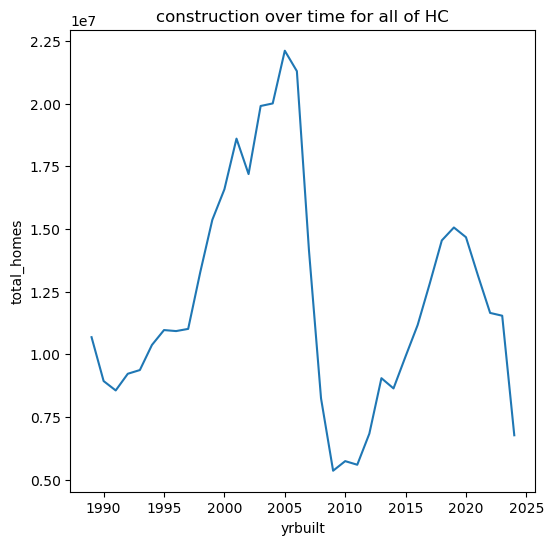

In [677]:
# Look at construction over time for all of HC
plt.figure(figsize=(6,6))
sns.lineplot(x='yrbuilt',y='total_homes',data=annual_built)
#plt.yscale('log')
plt.title('construction over time for all of HC')
plt.show()

Construction Data doesn't have a linear trend at all - and actually that does make a little sense.

When considering the timing and state of the economy amd what was happening at that time, 2009 was the "great recession" and very specifically in real estate.
The bubble loans and lending behvaior of the banks led to significant sales of homes followed by the massive drop when the market collapsed.

In recent time, at the advent of the COVID crisis, real estate demand soared with low bank rates. We see that pattern again and the drop in the most recent years.

This is relatively unexpected - while construction rate is a good approximation for demand, it's correlation with ecosystem health is potentially less clear.
All data still needs to be scaled so it can be used for the construction of the index. Furthermore, it is possible to engineer supplementary metrics that would aid in analysis.

Construction Data needs to be scaled so that it can be used in the index

In [709]:
annual_built.head(4)

,total_homes
yrbuilt,
1989,10680930
1990,8929130
1991,8555327
1992,9220968


In [706]:
annual_built.shape

(36, 1)

In [699]:
annbuilt_input=annual_built.drop(columns='yrbuilt',inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_6980\211281170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annbuilt_input=annual_built.drop(columns='yrbuilt',inplace=True)


In [708]:
annbuilt_input

In [703]:
# Creating values scaled to a range of 0-1
scaler = MinMaxScaler()
#fit,transform
houses_built_scaled = scaler.fit_transform(annbuilt_input)

ValueError: Expected 2D array, got scalar array instead:
array=nan.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [702]:
# New standardized df
houses_built_scaled.shape

(144, 1)

In [697]:
construction_scale=pd.DataFrame(houses_built_scaled)

In [698]:
construction_scale

,0
0,0.317973
1,0.317973
2,0.317973
3,0.317973
4,0.213445
...,...
139,0.369063
140,0.084387
141,0.084387
142,0.084387


In [696]:
construction_scale['year']=annbuilt.index

ValueError: Length of values (36) does not match length of index (144)

In [684]:
construction_scale['number_built']=annbuilt.sum

In [685]:
construction_scale

,0,number_built
0,0.317973,<bound method DataFrame.sum of mean ...
1,0.317973,<bound method DataFrame.sum of mean ...
2,0.317973,<bound method DataFrame.sum of mean ...
3,0.317973,<bound method DataFrame.sum of mean ...
4,0.213445,<bound method DataFrame.sum of mean ...
...,...,...
139,0.369063,<bound method DataFrame.sum of mean ...
140,0.084387,<bound method DataFrame.sum of mean ...
141,0.084387,<bound method DataFrame.sum of mean ...
142,0.084387,<bound method DataFrame.sum of mean ...


In [609]:
construction_scale.iloc[:,0].head(2)

0    0.317973
1    0.213445
Name: scaled, dtype: float64

In [605]:
print(construction_scale.columns)
construction_scale.columns=['scaled','year']
construction_scale.head(3)

Index(['scaled', 'year'], dtype='object')


,scaled,year
0,0.317973,1989
1,0.213445,1990
2,0.191140,1991


## Housing, Population Density and Change

The impact of coastal development extends beyond the shoreline. In an estuarine environment, the watersheds that feed into the estuary (or in the case the bay) are equally important. Using a highway as a physical boundary overlapped with a map of the various watersheds, a representative set of properties, the type, their acreage and the year that they were built will be used as an estimate and proxy for coastline development.  Based on research literature, concentration of non-organic nitrates and phosphates will serve as a proxy for the introduction of artificial damaging compounds - however, in the construction of more complex models, more granular data can be used.

In [440]:
## New Construction estimates by year

In [529]:
# Get annual change of homes built on hillsborough bay coast from 1990-present
perchange=[]
year=1989
year1=[]
x_base=[]
x1=[]
for x in range(1989,1989+len(dfyearbuilt)):
    if x==0:
        continue
    elif x==1988+len(dfyearbuilt):
        break
    else:
        perchange.append(round((dfyearbuilt[x+1]/dfyearbuilt[x])*100,3))
        x_base.append(dfyearbuilt[x])
        x1.append(dfyearbuilt[x+1])
    year+=1
    year1.append(year)

NameError: name 'dfyearbuilt' is not defined

In [ ]:
perchange[0:5]

In [ ]:
dfperchange=pd.DataFrame()
dfperchange['percentchange']=perchange

In [442]:
dfperchange['x']=x_base
dfperchange['x+1']=x1
dfperchange['year']=year1

NameError: name 'dfperchange' is not defined

In [443]:
dfperchange.head(5)

NameError: name 'dfperchange' is not defined

In [444]:
dfprop[dfprop.YearBuilt>1989].groupby(['YearBuilt']).TotalNumBuildings.agg(['min', 'max', 'std', 'sum'])

,min,max,std,sum
YearBuilt,,,,
1990,1.0,4.0,0.443977,70.0
1991,1.0,2.0,0.152499,44.0
1992,1.0,1.0,0.000000,64.0
1993,1.0,7.0,0.929039,104.0
1994,1.0,1.0,0.000000,69.0
1995,1.0,1.0,0.000000,103.0
1996,1.0,2.0,0.130734,118.0
1997,1.0,2.0,0.115470,76.0
1998,1.0,3.0,0.294418,107.0


In [528]:
dfacreage

NameError: name 'dfacreage' is not defined

In [446]:
# Describes number of houses built in subset data, total number of units per built structure
# Multi-unit buildings have an increased environmental impact per individual parcel
dfperchange_unit

NameError: name 'dfperchange_unit' is not defined

## Population Growth

In [11]:
### Looking into population statistics now

Data:
Regional population growth was difficult to define based on the resolution of data available.
2 sets of population data were initially used forming 2 baseline models:
- Data available specifically for the metro Tampa area
- WHO data for the entire Tampa Bay region.

Both models demonstrated the same growth patterns, as discussed below

The data and model aggregated at the highest level was used to match the scale of the data being considered in both development rates and nutrient loading
The second data set was more comprehensive in its total figures.

The expected outcome of a baseline model was to see exponential growth that would be matched by patterns in development; however, this was not the case.
In the 34 year time scale of the study, population growth was steady and displayed linear growth.

Values were scaled using a MinMax scaler for use as a standardized feature in the weighted API model.

In [20]:
### Create population DFs


In [114]:
dfpop=pd.DataFrame()
dfpop['year']=0
dfpop['sumpop']=0

In [286]:
sum(est_pop.iloc[:,1])

1655002.597663

In [116]:
dfpop_staged
## This file was originally a geodatabase file that has been read in as a CSV to access the non-geospatial data.

,wkt_geom,OBJECTID,SMOD_LEVEL,SMOD_ID,ISO,CNTRY_NAME,JRC_NAME_MAIN,JRC_NAME_LIST,CIESIN_NAME,CIESIN_NAME_TL,...,GHSPOP_R23_1985,GHSPOP_R23_1990,GHSPOP_R23_1995,GHSPOP_R23_2000,GHSPOP_R23_2005,GHSPOP_R23_2010,GHSPOP_R23_2015,GHSPOP_R23_2020,GHSPOP_R23_2025,GHSPOP_R23_2030
0,MultiPolygon (((-82.72100607199996603 28.37449...,12407,30,30_12407,USA,United States,Tampa,Tampa; Saint Petersburg; Clearwater; Brandon; ...,Tampa,Tampa,...,1.333843e+06,1.480168e+06,1.601766e+06,1.717621e+06,1.824984e+06,1.920968e+06,2.045045e+06,2.191664e+06,2.261370e+06,2.330530e+06
1,MultiPolygon (((-82.41634709599998132 27.71290...,101040,23,23_87924,USA,United States,Sun City Center,Sun City Center; Greater Sun Center; Ruskin; G...,"Greater Sun Center, Sun City Center","Greater Sun Center, Sun City Center",...,1.568739e+04,1.837320e+04,2.062473e+04,2.210739e+04,2.713719e+04,2.711277e+04,2.903848e+04,3.109123e+04,3.220606e+04,3.357573e+04
2,MultiPolygon (((-82.37805279399998426 27.81459...,101047,23,23_87931,USA,United States,Adamsville,Adamsville; North Ruskin; Apollo Beach,Apollo Beach,Apollo Beach,...,7.839934e+03,9.115709e+03,1.024629e+04,1.101930e+04,1.340539e+04,1.364281e+04,1.467739e+04,1.571192e+04,1.632053e+04,1.699778e+04
3,MultiPolygon (((-82.33898157599998058 27.82306...,101054,23,23_87938,USA,United States,Riverview,Riverview; Riverview,Panther Trace,Panther Trace,...,1.382634e+04,1.547221e+04,1.716790e+04,1.918479e+04,2.176125e+04,2.414159e+04,2.630752e+04,2.811921e+04,2.902663e+04,2.993258e+04
4,MultiPolygon (((-82.21098576599996477 27.84849...,101064,23,23_87948,USA,United States,Fishhawk,Fishhawk,Parkside Village,Parkside Village,...,4.166395e+03,4.651319e+03,5.197914e+03,5.798763e+03,6.694678e+03,7.502811e+03,8.249881e+03,8.864453e+03,9.098630e+03,9.350476e+03


In [113]:
dfpop_staged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   wkt_geom         5 non-null      object 
 1   OBJECTID         5 non-null      int64  
 2   SMOD_LEVEL       5 non-null      int64  
 3   SMOD_ID          5 non-null      object 
 4   ISO              5 non-null      object 
 5   CNTRY_NAME       5 non-null      object 
 6   JRC_NAME_MAIN    5 non-null      object 
 7   JRC_NAME_LIST    5 non-null      object 
 8   CIESIN_NAME      5 non-null      object 
 9   CIESIN_NAME_TL   5 non-null      object 
 10  AREA_SQKM        5 non-null      float64
 11  AREA_SQM         5 non-null      float64
 12  CIESIN_NAME_ADJ  5 non-null      object 
 13  ADJ              1 non-null      float64
 14  GHSPOP_R19_1975  5 non-null      object 
 15  GHSPOP_R19_1990  5 non-null      float64
 16  GHSPOP_R19_2000  5 non-null      float64
 17  GHSPOP_R19_2015  5 n

In [94]:
area_stage=pd.concat([dfpop_staged.CIESIN_NAME,dfpop_staged.AREA_SQKM],axis=1)

In [107]:
area_stage

,CIESIN_NAME,AREA_SQKM
0,Tampa,1745.422402
1,"Greater Sun Center, Sun City Center",42.796333
2,Apollo Beach,26.476118
3,Panther Trace,17.931987
4,Parkside Village,4.980987


In [124]:
dfpop_staged.AREA_SQKM

0    1745.422402
1      42.796333
2      26.476118
3      17.931987
4       4.980987
Name: AREA_SQKM, dtype: float64

In [117]:
est_pop=dfpop_staged.iloc[0:,21:29]

In [221]:
est_pop=pd.concat([dfpop_staged.AREA_SQKM,est_pop],axis=1)

In [283]:
est_pop.iloc[:,2]

0    1.717621e+06
1    2.210739e+04
2    1.101930e+04
3    1.918479e+04
4    5.798763e+03
Name: GHSPOP_R23_2000, dtype: float64

In [224]:
area=sum(est_pop.iloc[:,0])

In [225]:
area

1837.60782761

In [226]:
est_pop=est_pop.iloc[:,1:]

In [242]:
est_pop

,GHSPOP_R23_1990,GHSPOP_R23_1995,GHSPOP_R23_2000,GHSPOP_R23_2005,GHSPOP_R23_2010,GHSPOP_R23_2015,GHSPOP_R23_2020,GHSPOP_R23_2025
0,1.480168e+06,1.601766e+06,1.717621e+06,1.824984e+06,1.920968e+06,2.045045e+06,2.191664e+06,2.261370e+06
1,1.837320e+04,2.062473e+04,2.210739e+04,2.713719e+04,2.711277e+04,2.903848e+04,3.109123e+04,3.220606e+04
2,9.115709e+03,1.024629e+04,1.101930e+04,1.340539e+04,1.364281e+04,1.467739e+04,1.571192e+04,1.632053e+04
3,1.547221e+04,1.716790e+04,1.918479e+04,2.176125e+04,2.414159e+04,2.630752e+04,2.811921e+04,2.902663e+04
4,4.651319e+03,5.197914e+03,5.798763e+03,6.694678e+03,7.502811e+03,8.249881e+03,8.864453e+03,9.098630e+03


In [254]:
sum(est_pop.iloc[:,1])

1655002.597663

In [270]:
dfdf=pd.DataFrame(columns=['year','population','density'])

In [271]:
dfdf

,year,population,density


In [272]:
## Set up series for 5 year intervals
f=pd.Series()
density=pd.Series()
counter=1990

for x in est_pop.columns:
    pop_temp=sum(est_pop[x])
    dfdf['year']=counter
    f[counter]=sum(est_pop[x])
    density[counter]=sum(est_pop[x])/area
    counter=counter+5
    
    
    #print(sum(est_pop[x])/area)

In [281]:
pop_data=pd.concat([f,density],axis=1)
pop_data.columns=['population','density']
pop_data.reset_index(names=['year'],inplace=True)
pop_data

,year,population,density
0,1990,1.527781e+06,831.396548
1,1995,1.655003e+06,900.628835
2,2000,1.775731e+06,966.327417
3,2005,1.893982e+06,1030.678157
4,2010,1.993368e+06,1084.762411
5,2015,2.123318e+06,1155.479474
6,2020,2.275451e+06,1238.267758
7,2025,2.348022e+06,1277.760096


In [59]:
population_density

0    16572.910464
1    17952.974526
2    19262.598326
3    20545.354496
4    21623.460377
5    23033.121681
6    24683.408574
7    25470.641785
Name: 0, dtype: float64

In [503]:
LinReg_WHO_den=LinearRegression()

In [504]:
LinReg_WHO_pop=LinearRegression()

In [432]:
X=pop_data.year
y=pop_data.population

In [505]:
LinReg_WHO_pop.fit(pop_data.year.to_frame(),pop_data.population)

LinearRegression()

In [506]:
LinReg_WHO_den.fit(pop_data.year.to_frame(),pop_data.density)

LinearRegression()

In [507]:
pred_WHO_pop_pred=LinReg_WHO_pop.predict(pop_metro.year.to_frame())

In [508]:
pred_WHO_den_pred=LinReg_WHO_den.predict(pop_metro.year.to_frame())

In [522]:
pop_metro

,year,population,index,"percent_change,",percent_state,percent_national;,WHO_popreg_pred,WHO_popreg_dens,WHO_popreg_prd,WHO_denreg_pred
0,1969,483694,100.000000,N,7.283451,0.240288,1.033692e+06,562.520265,1.033692e+06,562.520265
1,1970,493409,102.008501,2.008501243,7.207941,0.242106,1.057468e+06,575.459027,1.057468e+06,575.459027
2,1971,513136,106.086906,3.998102994,7.163676,0.248111,1.081244e+06,588.397789,1.081244e+06,588.397789
3,1972,533386,110.273437,3.946322223,7.092593,0.254873,1.105021e+06,601.336550,1.105021e+06,601.336550
4,1973,564604,116.727518,5.852797036,7.122454,0.267143,1.128797e+06,614.275312,1.128797e+06,614.275312
5,1974,586558,121.266338,3.88838903,7.052490,0.274949,1.152573e+06,627.214073,1.152573e+06,627.214073
6,1975,593254,122.650684,1.141575087,6.945418,0.275347,1.176350e+06,640.152835,1.176350e+06,640.152835
7,1976,601762,124.409647,1.434124338,6.920499,0.276604,1.200126e+06,653.091597,1.200126e+06,653.091597
8,1977,607712,125.639764,0.988762999,6.836707,0.276533,1.223903e+06,666.030358,1.223903e+06,666.030358
9,1978,620076,128.195925,2.03451635,6.790476,0.279190,1.247679e+06,678.969120,1.247679e+06,678.969120


In [515]:
pop_metro

,year,population,index,"percent_change,",percent_state,percent_national;,WHO_popreg_pred,WHO_popreg_dens
0,1969,483694,100.000000,N,7.283451,0.240288,562.520265,562.520265
1,1970,493409,102.008501,2.008501243,7.207941,0.242106,575.459027,575.459027
2,1971,513136,106.086906,3.998102994,7.163676,0.248111,588.397789,588.397789
3,1972,533386,110.273437,3.946322223,7.092593,0.254873,601.336550,601.336550
4,1973,564604,116.727518,5.852797036,7.122454,0.267143,614.275312,614.275312
5,1974,586558,121.266338,3.88838903,7.052490,0.274949,627.214073,627.214073
6,1975,593254,122.650684,1.141575087,6.945418,0.275347,640.152835,640.152835
7,1976,601762,124.409647,1.434124338,6.920499,0.276604,653.091597,653.091597
8,1977,607712,125.639764,0.988762999,6.836707,0.276533,666.030358,666.030358
9,1978,620076,128.195925,2.03451635,6.790476,0.279190,678.969120,678.969120


In [519]:
pop_metro['WHO_popreg_pred']=pd.Series(pred_WHO_pop_pred)
pop_metro['WHO_denreg_pred']=pd.Series(pred_WHO_den_pred)

In [520]:
pop_metro
#pop_metro.columns=['year','population','index','percent_change,','percent_state','percent_national']

,year,population,index,"percent_change,",percent_state,percent_national;,WHO_popreg_pred,WHO_popreg_dens,WHO_popreg_prd,WHO_denreg_pred
0,1969,483694,100.000000,N,7.283451,0.240288,1.033692e+06,562.520265,1.033692e+06,562.520265
1,1970,493409,102.008501,2.008501243,7.207941,0.242106,1.057468e+06,575.459027,1.057468e+06,575.459027
2,1971,513136,106.086906,3.998102994,7.163676,0.248111,1.081244e+06,588.397789,1.081244e+06,588.397789
3,1972,533386,110.273437,3.946322223,7.092593,0.254873,1.105021e+06,601.336550,1.105021e+06,601.336550
4,1973,564604,116.727518,5.852797036,7.122454,0.267143,1.128797e+06,614.275312,1.128797e+06,614.275312
5,1974,586558,121.266338,3.88838903,7.052490,0.274949,1.152573e+06,627.214073,1.152573e+06,627.214073
6,1975,593254,122.650684,1.141575087,6.945418,0.275347,1.176350e+06,640.152835,1.176350e+06,640.152835
7,1976,601762,124.409647,1.434124338,6.920499,0.276604,1.200126e+06,653.091597,1.200126e+06,653.091597
8,1977,607712,125.639764,0.988762999,6.836707,0.276533,1.223903e+06,666.030358,1.223903e+06,666.030358
9,1978,620076,128.195925,2.03451635,6.790476,0.279190,1.247679e+06,678.969120,1.247679e+06,678.969120


In [481]:
pop_metro['WHO_popreg_dens']=pred_WHO

In [ ]:
pop_metro

In [57]:
X_train,X_test,y_train,y_test = train_test_split(popden.year,popden.density, test_size=0.3, shuffle=False)

NameError: name 'popden' is not defined

In [461]:
model.fit(X_train,y_train)

NameError: name 'X_train' is not defined

In [462]:
model.score(X_test,y_test) 

NameError: name 'X_test' is not defined

In [463]:
den.to_csv('population_density.csv')

NameError: name 'den' is not defined

In [464]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\human Imact\\2024 Hillsborough Shape Files')
dev=gpd.read_file('Tampa_Bay_Development.shp')
dev_df=pd.read_csv('hc_shp.csv',encoding='cp1252',low_memory=False)
dev_df.info()
dev_df.head(10)
pwd
plt.figure(figsize=(50,50))
dev.plot(column='FLUCSDESC',figsize=(50,50))
#plt.plot(dev)
#plt.legend()
#plt.savefig('test.png')
plt.show()


NameError: name 'gpd' is not defined

In [465]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\human Imact\\Population Data')
pop_metro=pd.read_csv('tampa_metro_population.csv',header=0)
pop_metro.info()
pop_metro
sns.lineplot(x='Year',y='Population',data=pop_metro)
plt.xlabel='year'
plt.ylabel='Population'






sns.scatterplot(x='Year',y=np.log(pop_metro.Population),data=pop_metro)
plt.set_xlabel='Population (per 100k)'
plt.title('Tampa Regional Population Over Time')
plt.show()
LinRegLog=LinearRegression()
X=pop_metro.Year.to_frame()
y=pop_metro.Population
LinRegLog.fit(X,y)
LinRegLog.score(X,y)
LinRegLog.coef_
LinRegLog.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
LinRegLog.fit(X_train,y_train)
LinRegLog.score(X_train,y_train)
LinRegLog.score(X_test,y_test)

pwd
os.chdir('J:\\Brainstation\\BS Git\\Property Records\\GIS\\Zips\\')

SyntaxError: invalid syntax (2164171991.py, line 24)

In [291]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\human Imact\\Population Data')

In [292]:
pop_metro=pd.read_csv('tampa_metro_population.csv',header=0)

In [293]:
pop_metro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 54 non-null     int64  
 1   Population                           54 non-null     int64  
 2           Index                        54 non-null     float64
 3           Percent Change               54 non-null     object 
 4           Percent of Statewide Total   54 non-null     float64
 5           Percent of Nationwide Total  54 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 2.7+ KB


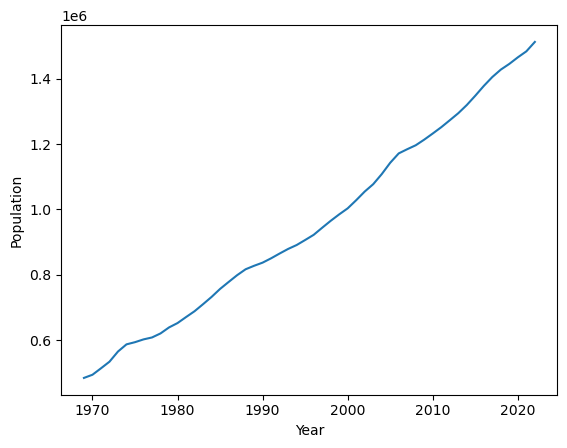

In [294]:
sns.lineplot(x='Year',y='Population',data=pop_metro)
plt.xlabel='year'
plt.ylabel='Population'

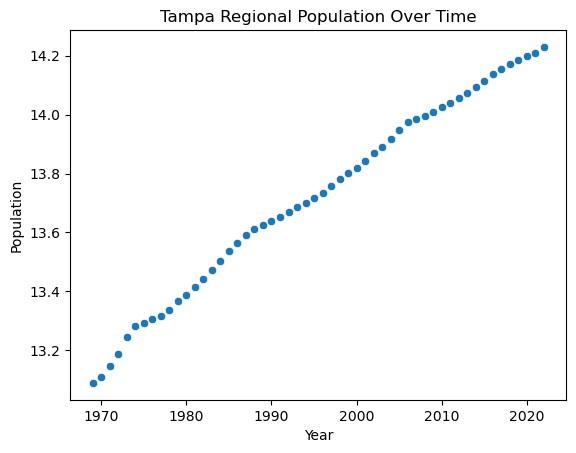

In [295]:

sns.scatterplot(x='Year',y=np.log(pop_metro.Population),data=pop_metro)
plt.set_xlabel='Population (per 100k)'
plt.title('Tampa Regional Population Over Time')
plt.show()

In [296]:
LinRegLog=LinearRegression()

In [297]:
X=pop_metro.Year.to_frame()
y=pop_metro.Population

In [298]:
LinRegLog.fit(X,y)

LinearRegression()

In [299]:
LinRegLog.score(X,y)

0.992766818417056

In [300]:
y_pred = LinRegLog.predict(X)


In [314]:
len(X)

54

In [317]:
ypred_values=pd.Series(y_pred)


In [326]:
X['Year']

0     1969
1     1970
2     1971
3     1972
4     1973
5     1974
6     1975
7     1976
8     1977
9     1978
10    1979
11    1980
12    1981
13    1982
14    1983
15    1984
16    1985
17    1986
18    1987
19    1988
20    1989
21    1990
22    1991
23    1992
24    1993
25    1994
26    1995
27    1996
28    1997
29    1998
30    1999
31    2000
32    2001
33    2002
34    2003
35    2004
36    2005
37    2006
38    2007
39    2008
40    2009
41    2010
42    2011
43    2012
44    2013
45    2014
46    2015
47    2016
48    2017
49    2018
50    2019
51    2020
52    2021
53    2022
Name: Year, dtype: int64

In [321]:
pd.Series(X)

ValueError: Data must be 1-dimensional, got ndarray of shape (54, 1) instead

In [334]:
regression_values=pd.concat([X.Year,ypred_values],axis=1)

In [337]:
regression_values.columns=['year','proj_pop']

In [342]:
sns.lineplot(x-'Year',y='proj_pop',data=regression_values)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

TypeError: unsupported operand type(s) for -: 'str' and 'str'

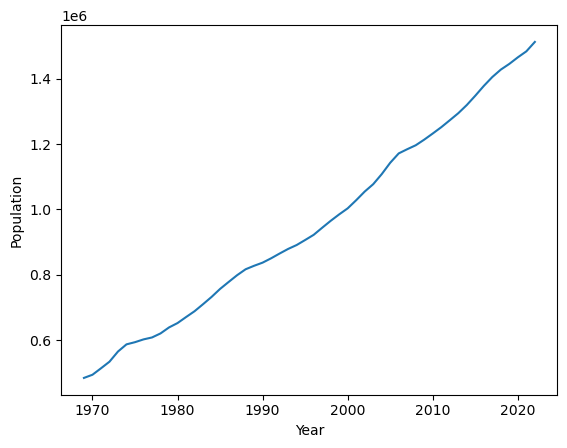

In [338]:
sns.lineplot(x='Year',y='Population',data=pop_metro)


In [354]:
yr=regression_values.year
pop=regression_values.proj_pop

In [373]:
val=pd.concat([yr,pop],axis=1)

<Axes: xlabel='year', ylabel='proj_pop'>

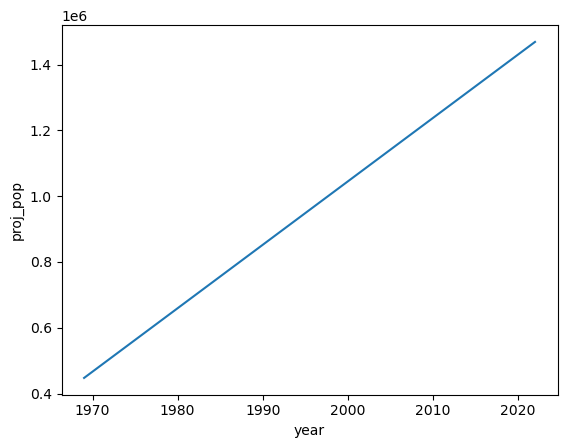

In [382]:
sns.lineplot(x=val.index,y='proj_pop',data=val)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
LinRegLog.fit(X_train,y_train)

In [ ]:
LinRegLog.score(X_train,y_train)

In [ ]:
LinRegLog.score(X_test,y_test)

In [392]:
testing=pd.concat([X,ypred_values],axis=1)

In [514]:
pop_metro

,year,population,index,"percent_change,",percent_state,percent_national;,WHO_popreg_pred,WHO_popreg_dens
0,1969,483694,100.000000,N,7.283451,0.240288,562.520265,562.520265
1,1970,493409,102.008501,2.008501243,7.207941,0.242106,575.459027,575.459027
2,1971,513136,106.086906,3.998102994,7.163676,0.248111,588.397789,588.397789
3,1972,533386,110.273437,3.946322223,7.092593,0.254873,601.336550,601.336550
4,1973,564604,116.727518,5.852797036,7.122454,0.267143,614.275312,614.275312
5,1974,586558,121.266338,3.88838903,7.052490,0.274949,627.214073,627.214073
6,1975,593254,122.650684,1.141575087,6.945418,0.275347,640.152835,640.152835
7,1976,601762,124.409647,1.434124338,6.920499,0.276604,653.091597,653.091597
8,1977,607712,125.639764,0.988762999,6.836707,0.276533,666.030358,666.030358
9,1978,620076,128.195925,2.03451635,6.790476,0.279190,678.969120,678.969120


In [409]:
pop_data[pop_data.year==1990].population

0    1.527781e+06
Name: population, dtype: float64

In [ ]:
os.chdir('J:\\Brainstation\\BS Git\\Property Records\\GIS\\
Zips\\')

In [413]:
pop_data

,year,population,density
0,1990,1.527781e+06,831.396548
1,1995,1.655003e+06,900.628835
2,2000,1.775731e+06,966.327417
3,2005,1.893982e+06,1030.678157
4,2010,1.993368e+06,1084.762411
5,2015,2.123318e+06,1155.479474
6,2020,2.275451e+06,1238.267758
7,2025,2.348022e+06,1277.760096


In [412]:
testing

,Year,0
0,1969,4.474433e+05
1,1970,4.667137e+05
2,1971,4.859841e+05
3,1972,5.052545e+05
4,1973,5.245249e+05
5,1974,5.437953e+05
6,1975,5.630657e+05
7,1976,5.823361e+05
8,1977,6.016064e+05
9,1978,6.208768e+05
